<p align="center">
  <img src="../references/assets/discogs-logo.png" alt="Discogs" width="200"/>
</p>

---
# **PROJET : Discogs — La musique électronique racontée par les données**

---
## **Partie 1 — Le cadre**

### **1.0 Contexte**

**Cette partie présente le cadre général du projet** : Contexte métier, questions de recherche, approche retenue, périmètre et limites.

**Objectif** : Aligner le lecteur sur ce que le notebook cherche à démontrer avant d’entrer dans la préparation des données.

**Sous-questions traitées** :
- **1.1** Pourquoi ce sujet et pourquoi Discogs ?
- **1.2** Quel est le dataset et sa granularité ?
- **1.3** Quelles questions principales le notebook adresse ?
- **1.4** Quel est le périmètre d’étude et le lexique des variables ?

**Concepts techniques mobilisés (vue globale)** :
- **Core ML** : dataset, features `X`, target `y`, training (`fit`), inference (`predict`), évaluation, généralisation.
- **Feature engineering** : extraction/normalisation logique de variables tabulaires et catégorielles.
- **Validation** : train/test temporel.
- **Métriques** : Accuracy, Balanced Accuracy, F1.

**À la fin, on veut obtenir :**
- Une lecture claire de la structure du marché électronique ;
- Un modèle capable de prédire la **désirabilité marchande** d'un vinyl (ratio want/have) et sa **collectabilité** (binaire) à partir de signaux API Discogs ;
- Une interprétation SHAP précise des facteurs qui font qu'un vinyl se collecte — rareté, ancienneté, label, prix.

&nbsp;

> **Notes** :
> - Cette partie sert de contrat de lecture pour tout le reste du notebook.
> - Les choix de périmètre définis ici impactent directement les résultats des parties suivantes.

### **1.1 Pourquoi ce sujet ?**

Je propose ce sujet pour travailler sur un cas **réel**, **riche** et **imparfait** : **Discogs**. L’intérêt principal est pédagogique et technique : on sort d’un dataset *“propre de cours”* pour affronter de vraies contraintes data (hétérogénéité des tags, valeurs manquantes, multiples labels/formats, ambiguïtés de métadonnées, granularité fine des objets).

Discogs est particulièrement adapté parce qu’une ligne correspond à une **release** (un pressage/une version) et non à une œuvre abstraite. Cette granularité permet d’analyser simultanément :
- La dynamique des **styles**,
- Le rôle des **formats** (`Vinyl`, `Digital`, etc.),

En résumé, ce projet est pertinent parce qu’il combine :
1. Un vrai enjeu de préparation/qualité de données,
2. Des méthodes de machine learning vues en formation,
3. Des résultats interprétables et exploitables pour la décision.

### **1.2 Le jeu de données**

**Fichiers de données (téléchargement)**

Les fichiers volumineux ne sont pas inclus dans le dépôt GitHub. Il faut les télécharger séparément et les placer dans les répertoires indiqués :

| Fichier | Taille | Où le placer | Téléchargement |
| --- | --- | --- | --- |
| `discogs_releases_electronic_20260201.csv` | 3.2 Go | `data/processed/` | [Google Drive](https://drive.google.com/file/d/1fMLlL0iKZ2PcEA02EdpK6VmYe68Jpj7b/view?usp=drive_link) |
| `discogs_electronic.pkl` | 1.4 Go | `data/interim/` | [Google Drive](https://drive.google.com/file/d/1-mIhUng0hQgZThnKutWRfa66DPSWJuRb/view?usp=drive_link) |
| `discogs_api_cache.pkl` | 312 Ko | `data/interim/` | [Google Drive](https://drive.google.com/file/d/1rJzEAO5gSimokoLDk3hwN57vl3nPsazX/view?usp=drive_link) |
| `.env.local` | — | racine du projet | [Google Drive](https://drive.google.com/file/d/1gL8dASiGonydDwV0AQIn-GO8X00g_dkA/view?usp=drive_link) *(lien privé)* |

**Détail de chaque fichier :**

- **`discogs_releases_electronic_20260201.csv`** — le dataset principal (3.2 Go). **Indispensable** : sans ce fichier, le notebook ne peut pas démarrer.
- **`discogs_electronic.pkl`** — cache prétraité généré automatiquement. Si vous avez le CSV, ce fichier sera recréé tout seul — vous n'êtes pas obligé de le télécharger.
- **`discogs_api_cache.pkl`** — résultats de l'enrichissement API (2 139 sorties). Permet d'éviter de refaire tous les appels API Discogs.
- **`.env.local`** — clés API Discogs (fichier privé). Sans ce fichier.

&nbsp;

> **Note** : Le chargement passe par un cache pickle (`data/interim/discogs_electronic.pkl`) — la première exécution parse le CSV complet (~30 s), les suivantes rechargent depuis le cache (~3 s).

**Source** : Dump XML mensuel public [data.discogs.com](https://data.discogs.com/) — snapshot du **01/02/2026**, parsé en streaming vers CSV via le script `discogs_dump_releases_xml_to_csv.py`.

**Fichier parsé** : `data/processed/discogs_releases_electronic_20260201.csv`

**Pipeline de construction** :

```
Discogs XML dump (~17 M releases)
    └── Filtre genre "Electronic"   → ~4,85 M releases
        └── Parsing streaming (gzip)   → CSV ~45 colonnes
            └── Cache pickle interim   → chargement rapide (~3 s)
```

**Volume et périmètre** :

| Dimension | Valeur |
|---|---|
| Releases Electronic brutes | ~4,8 M |
| Après filtre temporel (1970–2025) | ~4,6 M |
| Après filtre styles actifs | dépend de `ELECTRONIC_STYLES` |
| Colonnes chargées | 23 (`NEEDED_COLS`) |

**Colonnes disponibles** :

| Groupe | Colonnes |
|---|---|
| **Identifiants** | `release_id`, `master_id`, `is_main_release` |
| **Contenu** | `title`, `artist_names`, `artist_count`, `track_count`, `track_titles`, `track_positions`, `track_durations` |
| **Classification** | `genres`, `styles`, `data_quality` |
| **Sortie** | `released`, `released_year`, `country` |
| **Labels** | `label_names`, `label_ids`, `label_catnos` |
| **Formats** | `format_names`, `format_descriptions`, `format_qtys` |
| **Rôles** | `artist_roles`, `extraartist_roles` |

&nbsp;

> **Granularité** : 1 ligne = 1 release individuelle (pas un master — les ré-éditions et variations sont des lignes distinctes).

### **1.3 Ce que le notebook cherche à résoudre**

Le notebook suit un fil logique en 3 niveaux :

| Niveau | Question | Type d'approche |
|---|---|---|
| **Comprendre** | Comment le catalogue électronique est structuré (temps, formats, pays, labels, styles, artistes, œuvres) ? | EDA / visualisation |
| **Prédire** | Quels vinyls sont les plus convoités et collectibles ? Peut-on prédire leur valeur marchande ? | Régression + classification + API enrichissement |
| **Interpréter** | Quels signaux (rareté, prix, style, label) expliquent la collectabilité ? | SHAP / interprétabilité ML |

### **1.4 Périmètre stylistique**

Le notebook travaille sur le périmètre **Electronic** Discogs, avec découverte automatique des styles présents dans les données quand `ELECTRONIC_STYLES = None`.

- **Lexique Discogs (métier)** :

> Exemples basés sur la release : `Daft Punk - Homework` (`release_id`: `2947655`, [Lien](https://www.discogs.com/release/2947655)).
> <p align="center">
>   <span style="display:flex; justify-content:center; gap:16px; flex-wrap:wrap;">
>     <img src="../references/assets/daft_punk-homework-front.jpg" alt="Homework front" width="200"/>
>     <img src="../references/assets/daft_punk-homework-back.jpg" alt="Homework back" width="200"/>
>     <img src="../references/assets/daft_punk-homework-side_a.jpg" alt="Homework Side A" width="200"/>
>     <img src="../references/assets/daft_punk-homework-side_b.jpg" alt="Homework Side B" width="200"/>
>     <img src="../references/assets/daft_punk-homework-side_c.jpg" alt="Homework Side C" width="200"/>
>     <img src="../references/assets/daft_punk-homework-side_d.jpg" alt="Homework Side D" width="200"/>
>   </span>
> </p>

| Terme | Définition |
|---|---|
| **`release`** | Pressage individuel d'une œuvre (ex : `Daft Punk - Homework`, édition `Europe`, `2xLP`) |
| **`release_id`** | Identifiant unique Discogs de release (ex: `2947655`) |
| **`master_id`** | Identifiant unique Discogs de la fiche master qui regroupe les variantes d'une même œuvre (ex: `26629` pour la fiche master `Daft Punk - Homework`. Cela permet de différencier les releases qui peuvent exister en `Digital`, `Vinyl`, `CD`, `Tape`, `Video` ou `Others`) |
| **`title`** | Titre de la release (ex: `Homework`) |
| **`artist_names`** | Noms des artistes crédités sur la release (ex: `Daft Punk`) |
| **`artist_roles`** | Rôles des artistes principaux (producer, remixer, etc.; ex: `Producer`, `DJ`) |
| **`extraartist_roles`** | Rôles des contributeurs additionnels (crédits techniques/artistiques; ex: `Mastered By`, `Featuring`) |
| **`released`** | Date de sortie textuelle (quand disponible; ex: `1997-01-20`) |
| **`released_year`** | Année de sortie de la release (ex: `1997`) |
| **`country`** | Pays (ou zone) attribué à la release (ex: `Europe`) |
| **`genres`** | Genres Discogs associés à la release (champ multi-valeurs; ex: `Electronic`) |
| **`styles`** | Styles Discogs associés à la release (champ multi-valeurs; ex: `House`, `Techno`, `Electro`, `Disco`, `French House`) |
| **`label_names`** | Noms des labels associés à la release (ex: `Virgin`, `Soma Quality Recordings`) |
| **`label_ids`** | Identifiant unique Discogs des labels (ex: IDs correspondants à `Virgin` "`750`" et à `Soma Quality Recordings` "`18`") |
| **`label_catnos`** | Numéros de catalogue label (catno; ex: `V 2821`, `7243 8 42609 1 0`) |
| **`format_names`** | Supports/formats principaux (`Vinyl`, `CD`, `File`, `Cassette`...; ex: `Vinyl`) |
| **`format_descriptions`** | Descriptions éditoriales des formats (`LP`, `12"`, `EP`, `Limited`, `Reissue`...; ex: `LP`, `Album`, `Stereo`) |
| **`format_qtys`** | Quantité par format (ex: `2` pour un `2xLP`) |
| **`track_titles`** | Titres des morceaux de la release (ex: `Daftendirekt`, `Around The World`) |
| **`track_positions`** | Positions des morceaux dans la tracklist (ex: `A1`, `B1`) |
| **`track_durations`** | Durées des morceaux (quand disponibles; ex: `2:44`, `7:07`) |
| **`artist_count`** | Nombre d'artistes principaux crédités (ex: `1`) |
| **`track_count`** | Nombre de morceaux dans la release (ex: `16`) |
| **`is_main_release`** | Indique si la release est marquée comme version principale (ex: `True` = version principale, `False` = variante) |
| **`data_quality`** | Indicateur de qualité des métadonnées Discogs (ex: `Correct`, `Needs Vote`) |

---
## **Partie 2 — Préparation des données**

### **2.0 Contexte**

**Cette partie prépare le corpus de travail** : Chargement, contrôle qualité, création de variables dérivées, puis application des filtres finaux.

**Objectif** : Construire une base de données propre, cohérente et robuste, qui servira à toutes les analyses et modèles du notebook.

**Sous-questions traitées** :
- **2.1** Quels imports et paramètres globaux pilotent le notebook ?
- **2.2** Comment charger les colonnes utiles sans alourdir l’exécution ?
- **2.3** Quelle est la qualité des données brutes (manquants, distribution, cohérence) ?
- **2.4** Quelles variables dérivées crée-t-on et pourquoi ?
- **2.5** Quels filtres finaux définissent le périmètre analytique ?

**Concepts techniques mobilisés (Partie 2)** :
- **Dataset** : Définition du corpus d’apprentissage/analyse.
- **Features (X)** : Variables numériques, catégorielles, binaires et temporelles.
- **Feature engineering** : Extraction (`style_first`, `label_first`, `format_cat`, flags binaires), agrégation temporelle.
- **Types de features** : Numerical, categorical, binary, time-based.
- **Préparation à la modélisation** : Cohérence des variables pour la partie supervisée (`X`) et la cible (`y`) créée en Partie 4.

&nbsp;

> **Notes** :
> - Toute la suite dépend de cette partie : une mauvaise préparation fausse les conclusions.
> - Les choix de mapping (`format_cat`, `style_first`, etc.) doivent rester cohérents sur l’ensemble du notebook.

### **2.1 Paramètres et imports**

**Ce que fait la cellule suivante** : Charge les bibliothèques Python et initialise les paramètres globaux qui pilotent tout le notebook (filtres, Top N, graine aléatoire, options temporelles, etc.).

**Ce qu'on cherche à lire / obtenir** :
- Un point de configuration unique, lisible et reproductible pour éviter les réglages dispersés dans les cellules d'analyse.

**Pourquoi ces outils ici ?**
- `pandas` / `numpy` : Base fiable pour manipulation tabulaire et calculs.
- `plotly` : Visualisations interactives lisibles pour soutenance.
- `scikit-learn` : Pipelines, modèles et métriques standard pour classification.

&nbsp;

> **Notes** :
> - Toute modification des constantes en 2.1 doit être suivie d'un rerun des cellules dépendantes.
> - Cette cellule fixe le cadre méthodologique de la suite

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter
from itertools import combinations
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, ConfusionMatrixDisplay)

# ── Styles électroniques cibles — périmètre de l'étude ───────────────────────
# None = mode AUTO : utiliser tous les styles observés dans le dataset Electronic au lieu d'une liste curatée figée.
ELECTRONIC_STYLES = None

# ── Filtres temporels optionnels ─────────────────────────────────────────────
# Laisser à None pour analyser l'intégralité du périmètre.
# Les trois filtres sont cumulatifs : seules les releases qui satisfont TOUS
# les critères non-None sont conservées.
#
# Exemples d'usage :
#   FILTER_DECADES  = ["1990s", "2000s"]  → uniquement les années 90 et 2000
#   FILTER_YEAR_MIN = 1988                → à partir de 1988 (inclusif)
#   FILTER_YEAR_MAX = 2010                → jusqu'à 2010 (inclusif)
#   Combiné : FILTER_YEAR_MIN=1993, FILTER_YEAR_MAX=1999 → "les années 90 exactes"
FILTER_DECADES  = ["1970s", "1980s", "1990s", "2000s", "2010s", "2020s"]    # list[str] | None   — ex: ["1990s", "2000s"]
FILTER_YEAR_MIN = 1970                                                      # int | None         — ex: 1985
FILTER_YEAR_MAX = 2025                                                      # ex: 2015

# ── Validation temporelle — split train / test ────────────────────────────────
# Année de coupure pour le split train (< seuil) / test (>= seuil).
# None = calculé automatiquement au 80e percentile des années du dataset filtré.
# Fixer manuellement pour reproduire une coupure précise :
#   TEMPORAL_SPLIT_YEAR = 2000   → train années 80-90s / test 2000s+
#   TEMPORAL_SPLIT_YEAR = 2010   → test = ère post-streaming
TEMPORAL_SPLIT_YEAR = None   # int | None

# ── Grain temporel des graphiques ─────────────────────────────────────────────
# Contrôle l'axe X de tous les graphiques temporels du notebook.
#   "auto"   → année si le périmètre filtré couvre ≤ 20 ans, décennie sinon
#   "year"   → toujours afficher par année (released_year)
#   "decade" → toujours afficher par décennie
TIME_GRAIN = "year"  # "auto" | "year" | "decade"

# ── Paramètres globaux ────────────────────────────────────────────────────────
RANDOM_STATE      = 42             # seed pour la répétabilité des résultats
SAMPLE_N          = 4_850_000      # max samples pour la classification   (réduire à 500_000 si RAM limitée)
TOP_STYLES_N      = 10             # nombre de styles affichés (Top N, sans regroupement résiduel)
TOP_LABELS_N      = 10             # nombre de labels affichés dans l'EDA
TOP_PAYS_N        = 10             # nombre de pays affichés dans les vues géographiques
TOP_ORIENTATION_N = 10             # nb d'extrêmes par côté (Digital et Vinyl)
TOP_RELEASES_N    = 10             # nombre de releases affichées
TOP_ARTISTS_N     = 10             # nombre d'artistes affichés
MIN_STYLE_N       = 300            # releases minimum pour qu'un style soit retenu en classification


NON_COUNTRY = {
    "Europe", "UK & Europe", "UK, Europe & US", "USA & Canada",
    "Scandinavia", "Worldwide", "Unknown"
}
LABELS_EXCLUDE = {"Unknown", "Not On Label", "", "Self-Released", "Promo"}
GENERIC_ARTISTS = {"Unknown", "Unknown Artist", "Various"}

THEME = "plotly_dark"  # thème Plotly pour les graphiques

print(f"Setup OK | RANDOM_STATE={RANDOM_STATE} | SAMPLE_N={SAMPLE_N:,} | THEME={THEME}")
if ELECTRONIC_STYLES is None:
    print("Périmètre : AUTO (tous les styles observés dans les données Electronic)")
else:
    print(f"Périmètre : {len(ELECTRONIC_STYLES)} styles électroniques définis")
print(f"Filtre temporel : DECADES={FILTER_DECADES} | YEAR=[{FILTER_YEAR_MIN}, {FILTER_YEAR_MAX}]")
print(f"Split validation : TEMPORAL_SPLIT_YEAR={'auto (80e pct)' if TEMPORAL_SPLIT_YEAR is None else TEMPORAL_SPLIT_YEAR}")
print(f"Grain temporel  : TIME_GRAIN={TIME_GRAIN}")

Setup OK | RANDOM_STATE=42 | SAMPLE_N=4,850,000 | THEME=plotly_dark
Périmètre : AUTO (tous les styles observés dans les données Electronic)
Filtre temporel : DECADES=['1970s', '1980s', '1990s', '2000s', '2010s', '2020s'] | YEAR=[1970, 2026]
Split validation : TEMPORAL_SPLIT_YEAR=auto (80e pct)
Grain temporel  : TIME_GRAIN=year


### **2.2 Chargement**

**Ce que fait la cellule suivante** : Charge le CSV sur les colonnes définies dans `NEEDED_COLS`, puis crée/met à jour un cache Pickle pour accélérer les exécutions suivantes.

**Ce qu’on cherche à lire / obtenir** :
- Un dataset exploitable rapidement, avec les champs strictement nécessaires aux analyses du notebook.

&nbsp;

> **Notes** :
> - Le cache est rafraîchi automatiquement si des colonnes de `NEEDED_COLS` manquent.
> - Les filtres analytiques ne sont pas appliqués ici : cette étape prépare la base de travail.

In [3]:
DATA_PATH  = Path("../data/processed/discogs_releases_electronic_20260201.csv")
CACHE_PATH = Path("../data/interim/discogs_electronic.pkl")

NEEDED_COLS = [
    "release_id", "master_id", "title", "artist_names", "track_titles",
    "released", "released_year", "genres", "styles", "country",
    "label_names", "label_ids", "label_catnos",
    "format_names", "format_descriptions", "format_qtys",
    "track_positions", "track_durations",
    "artist_roles", "extraartist_roles",
    "is_main_release", "artist_count", "track_count", "data_quality",
]

if CACHE_PATH.exists():
    print("Cache Pickle trouvé — chargement rapide...")
    df_raw = pd.read_pickle(CACHE_PATH)

    # Si le cache ne contient pas les nouvelles colonnes demandées,
    # on recharge le CSV et on rafraîchit le cache.
    missing_cols = [col for col in NEEDED_COLS if col not in df_raw.columns]
    if missing_cols:
        print(f"Cache incomplet (colonnes manquantes: {missing_cols}) — rechargement CSV...")
        df_raw = pd.read_csv(DATA_PATH, usecols=NEEDED_COLS, low_memory=False)
        df_raw.to_pickle(CACHE_PATH)
        print(f"Cache mis à jour : {CACHE_PATH}")
else:
    print("Premier chargement — lecture CSV (~1 min pour ~5M lignes)...")
    df_raw = pd.read_csv(DATA_PATH, usecols=NEEDED_COLS, low_memory=False)

    df_raw.to_pickle(CACHE_PATH)
    print(f"Cache créé : {CACHE_PATH}")

print(f"\nDimensions : {df_raw.shape}")
print(f"Colonnes   : {df_raw.columns.tolist()}")
df_raw.head(10)

Cache Pickle trouvé — chargement rapide...

Dimensions : (4850419, 24)
Colonnes   : ['release_id', 'title', 'country', 'released', 'released_year', 'data_quality', 'master_id', 'is_main_release', 'artist_names', 'artist_roles', 'artist_count', 'extraartist_roles', 'label_names', 'label_ids', 'label_catnos', 'format_names', 'format_qtys', 'format_descriptions', 'genres', 'styles', 'track_count', 'track_positions', 'track_titles', 'track_durations']


,release_id,title,country,released,released_year,data_quality,master_id,is_main_release,artist_names,artist_roles,...,label_catnos,format_names,format_qtys,format_descriptions,genres,styles,track_count,track_positions,track_titles,track_durations
0,1,Stockholm,Sweden,1999-03-00,1999,Needs Vote,1660109,True,The Persuader,NaN,...,SK032,Vinyl,2,"12""|33 ⅓ RPM",Electronic,Deep House,6,A|B1|B2|C1|C2|D,Östermalm|Vasastaden|Kungsholmen|Södermalm|Nor...,4:45|6:11|2:49|5:38|4:52|5:16
1,2,Knockin' Boots (Vol 2 Of 2),Sweden,1998-06-00,1998,Correct,713738,True,Mr. James Barth & A.D.,NaN,...,SK 026|SK026,Vinyl,1,"12""|33 ⅓ RPM",Electronic,Broken Beat|Techno|Tech House,4,A1|A2|B1|B2,A Sea Apart|Dutchmaster|Inner City Lullaby|Yea...,5:08|4:21|4:22|4:46
2,3,Profound Sounds Vol. 1,US,1999-07-13,1999,Correct,66526,False,Josh Wink,NaN,...,CK 63628|CK 63628|63628|63628,CD,1,Compilation|Mixed,Electronic,Techno|Tech House,14,1|2|3|4|5|6|7|8|9|10|11|12|13|14,D2|Anjua (Sneaky 3)|When The Funk Hits The Fan...,7:00|5:28|5:25|4:27|5:36|3:37|5:03|5:42|5:47|6...
3,4,Moving Cities,US,1999-11-02,1999,Needs Vote,104980,False,Faze Action,NaN,...,9 47555-2|9 47555-2,CD,1,Album,Electronic,House|Deep House,12,1|2|3|4|5|6|7|8|9|10|11|12,Moving Cities|To Love Is To Grow|Isis|Heartbea...,6:24|5:15|5:39|5:45|5:57|5:46|5:13|6:42|7:46|8...
4,5,Flowerhead,Germany,1995-01-15,1995,Correct,169944,True,Datacide,NaN,...,RI 026|RI026,CD,1,Album|Limited Edition,Electronic,Abstract|Ambient|Downtempo,5,1|2|3|4|5,Flashback Signal|Flowerhead|Deep Chair|So Much...,15:54|9:33|14:05|12:02|13:05
5,6,Knockin' Boots (Vol 1 Of 2),Sweden,1998-05-00,1998,Complete and Correct,713737,True,Mr. James Barth & A.D.,NaN,...,SK025|SK 025,Vinyl,1,"12""|33 ⅓ RPM",Electronic,Techno|Tech House,3,A1|B1|B2,It's All James|Above The Skyline|Suckin' Neck,5:29|5:01|5:04
6,7,Moonchildren EP,US,2000-02-00,2000,Needs Vote,267770,True,Moonchildren,NaN,...,D4L12002,Vinyl,1,"12""|33 ⅓ RPM|EP",Electronic,Deep House,3,A|AA1|AA2,Ran Away|Silent Crying|No Other,6:45|6:28|5:18
7,8,Spreading Outward EP,US,2000,2000,Needs Vote,48282,True,Sweet Abraham,NaN,...,D4L12004,Vinyl,1,"12""|EP",Electronic,Deep House,3,A|AA1|AA2,Diaspora|Wallflower|Days Since Past,7:15|7:25|6:28
8,9,Pure,US,2000,2000,Needs Vote,595959,True,Blue Six,NaN,...,NM008,Vinyl,1,"12""|33 ⅓ RPM",Electronic,House|Deep House,4,A1|A2|B1|B2,Pure (Mig's Petalpusher Vocal)|Pure (Jay's Ori...,7:02|4:30|6:50|6:45
9,10,You Are Love,US,1999-08-00,1999,Correct,160011,True,Lovetronic,NaN,...,NM003|nm 003,Vinyl,1,"12""|33 ⅓ RPM",Electronic,Deep House,4,A1|A2|B1|B2,You Are Love (Jay's Afrotronic Vocal)|You Are ...,7:46|7:30|7:46|8:05


### **2.3 Qualité des données**

**Ce que fait la cellule suivante** : Auditer la qualité des données (valeurs manquantes, couverture temporelle, diversité des styles) avant de construire les variables métier.

**Ce qu’on cherche à lire / obtenir** :
- Les champs potentiellement fragiles ;
- Le niveau de complétude pour les analyses temporelles ;
- La cohérence entre le filtre `genre=Electronic` et les styles observés.

&nbsp;

> **Notes** :
> - Sur Discogs, `genre` et `style` sont indépendants : une release peut être `Electronic` avec un style `Pop Rock` ou `Noise`.
> - Avec `ELECTRONIC_STYLES=None`, le mode AUTO conserve tous les styles observés ; une liste explicite rend le périmètre plus strict.

In [ ]:
# ── Diagnostic qualité ────────────────────────────────────────────────────
# Objectif : évaluer la couverture et la complétude du dataset brut avant
# feature engineering. On vérifie : taux de nulls par colonne, plage temporelle,
# diversité géographique, et diversité des styles observés.

missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
print("Valeurs manquantes (%) :")
print(missing_pct)

year_clean = pd.to_numeric(df_raw["released_year"], errors="coerce")
print(f"\nPériode couverte : {year_clean.min():.0f} – {year_clean.max():.0f}")
print(f"Releases sans année : {year_clean.isna().sum():,}")

print(f"\nPays distincts : {df_raw['country'].nunique()}")

# ── Tous les styles présents dans le dataset (champ pipe-séparé) ──────────────────────────────────────────────────────────
all_styles_series = (
    df_raw["styles"]
    .dropna()
    .str.split("|")
    .explode()
    .str.strip()
)
all_style_counts = all_styles_series.value_counts()

print(f"\nNombre total de styles distincts dans les données : {len(all_style_counts)}")
print("\nTop 20 styles bruts (dans le périmètre Electronic, avant filtre ELECTRONIC_STYLES) :")
print(all_style_counts.head(20))

# ── Couverture du périmètre styles ──────────────────────────────────────────────────────────
if ELECTRONIC_STYLES is None:
    # Mode AUTO : on prend tous les styles observés dans les données Electronic.
    ELECTRONIC_STYLES = sorted(all_style_counts.index.tolist())
    print("\n── Périmètre styles (AUTO) ─────────────────────────────────────────────")
    print(f"Tous les styles observés sont retenus : {len(ELECTRONIC_STYLES)} styles")
else:
    print("\n── Couverture de la liste de styles fournie ───────────────────────────")
    in_data = {s: all_style_counts.get(s, 0) for s in ELECTRONIC_STYLES}
    present = {s: n for s, n in in_data.items() if n > 0}
    absent = [s for s, n in in_data.items() if n == 0]

    coverage_df = (
        pd.Series(present)
        .sort_values(ascending=False)
        .rename("releases")
        .to_frame()
    )
    print(coverage_df.to_string())
    if absent:
        print(f"\nStyles du périmètre absents du dataset ({len(absent)}) : {absent}")
    else:
        print(f"\nTous les {len(ELECTRONIC_STYLES)} styles du périmètre sont présents dans les données.")

print(f"\nNote : des styles hors-périmètre (Pop Rock, Noise, Experimental…) apparaissent")
print(f"car sur Discogs, genre et style sont indépendants — une release peut avoir")
print(f"genre=Electronic et style=Pop Rock (ex: Synth-pop classé Electronic par la communauté).")
print(f"En mode AUTO (ELECTRONIC_STYLES=None), ils restent inclus dans l'analyse.")

Valeurs manquantes (%) :
artist_roles           100.000000
extraartist_roles       53.720555
track_durations         25.849787
released                 4.260312
released_year            4.260312
country                  4.258024
format_descriptions      2.001497
track_positions          0.167656
label_ids                0.016081
label_catnos             0.007072
styles                   0.001691
title                    0.001464
track_titles             0.000536
artist_names             0.000041
track_count              0.000000
genres                   0.000000
release_id               0.000000
format_qtys              0.000000
format_names             0.000000
artist_count             0.000000
is_main_release          0.000000
master_id                0.000000
data_quality             0.000000
label_names              0.000000
dtype: float64

Période couverte : 0 – 2026
Releases sans année : 206,644

Pays distincts : 247

Nombre total de styles distincts dans les données : 732

Top 2

### **2.4 Variables créées**

**Ce que fait la cellule suivante** : Construire les variables dérivées (styles, formats, temps, labels) qui servent de socle à toutes les analyses et visualisations.

**Ce qu’on cherche à lire / obtenir** : Un jeu de variables cohérent, interprétable et réutilisable dans tout le notebook.

**Variables clés** :
- `style_first` — Premier style Discogs (proxy technique de lecture stylistique)
- `style_count` — Nombre d’items dans `styles`
- `format_cat` — `Vinyl` / `CD` / `Tape` / `Digital` / `Video` / `Others`
- `is_vinyl` — Binaire aligné avec `format_cat == "Vinyl"`
- `decade` — Décennie de sortie
- `label_first` — Premier label Discogs
- `release_type`, `vinyl_size` — Extraits de `format_descriptions`

&nbsp;

> **Notes** :
> - Les helpers centralisent les règles de parsing/normalisation pour éviter les incohérences entre sections.
> - Les tableaux d’audit de cette cellule servent de validation métier rapide (formats, genres, distributions).

In [5]:
work = df_raw.copy()

# ── Nettoyage année ───────────────────────────────────────────────────────────
work["released_year"] = pd.to_numeric(work["released_year"], errors="coerce")
work = work[work["released_year"].between(1950, 2026)].copy()

# ── Helpers ───────────────────────────────────────────────────────────────────
def normalize_text(s):
    """Normalise un texte: strip + casse uniforme; retourne chaîne vide sinon."""
    return s.strip().casefold() if isinstance(s, str) else ""

def parse_items(s, sep="|"):
    """Retourne la liste d'items nettoyés d'un champ pipe-séparé."""
    if not isinstance(s, str) or not s.strip():
        return []
    return [x.strip() for x in s.split(sep) if x.strip()]

def extract_first(s, sep="|"):
    """Retourne le premier item d'un champ pipe-séparé."""
    parts = parse_items(s, sep=sep)
    return parts[0] if parts else "Unknown"

def count_items(s, sep="|"):
    """Compte le nombre d'items dans un champ pipe-séparé."""
    return len(parse_items(s, sep=sep))

def to_decade(y):
    """Convertit une année en décennie (ex: 1997 -> 1990s)."""
    try:
        return f"{(int(y) // 10) * 10}s"
    except (TypeError, ValueError):
        return "Unknown"

def extract_release_type(s):
    """Extrait le type éditorial principal depuis format_descriptions."""
    text = normalize_text(s)
    if not text:
        return "Unknown"

    # L'ordre impose la priorité métier en cas de co-occurrence.
    type_patterns = [
        ("Maxi-Single", ["maxi-single"]),
        ("Mini-Album", ["mini-album"]),
        ("Compilation", ["compilation"]),
        ("Album", ["album"]),
        ("Sampler", ["sampler"]),
        ("Single", ["single"]),
        ("EP", ["ep"]),
        ("LP", ["lp"]),
    ]
    for label, patterns in type_patterns:
        if any(p in text for p in patterns):
            return label
    return "Unknown"

def extract_vinyl_size(s):
    """Extrait la taille physique du vinyl depuis format_descriptions."""
    if not isinstance(s, str):
        return "Unknown"
    if '12"' in s:
        return '12"'
    if '7"' in s:
        return '7"'
    if '10"' in s:
        return '10"'
    return "Unknown"

def extract_format_cat(s):
    """Catégorie principale du format (basée sur le premier format pipe-séparé)."""
    first = extract_first(s)
    first_norm = normalize_text(first)

    # All Media et Box Set ne sont pas des supports précis -> Others.
    if "all media" in first_norm or "box set" in first_norm:
        return "Others"

    # Discogs: Lathe Cut, Acetate et Flexi-disc sont des formats vinyl.
    if (
        "vinyl" in first_norm
        or "lathe cut" in first_norm
        or "acetate" in first_norm
        or "flexi" in first_norm
    ):
        return "Vinyl"

    # Catégorie vidéo dédiée.
    if (
        "dvd" in first_norm
        or "vhs" in first_norm
        or "dvdr" in first_norm
        or "betacam sp" in first_norm
        or "blu-ray" in first_norm
    ):
        return "Video"

    if "laserdisc" in first_norm:
        return "CD"
    if "minidisc" in first_norm:
        return "Others"
    if "cdr" in first_norm or "cd" in first_norm:
        return "CD"
    if (
        "cassette" in first_norm
        or "8-track cartridge" in first_norm
        or "reel-to-reel" in first_norm
        or "reel to reel" in first_norm
    ):
        return "Tape"
    if "file" in first_norm:
        return "Digital"
    return "Others"


def extract_has_vinyl_sides(s):
    """1 si track_positions contient des lettres de face vinyl (A1, B2, C...), 0 sinon."""
    import re
    if not isinstance(s, str) or not s.strip():
        return 0
    items = [x.strip() for x in s.split("|") if x.strip()]
    for item in items:
        if re.match(r'^[A-F][A-F]?\d*$', item):
            return 1
    return 0

def extract_n_sides(s):
    """Nombre de faces vinyl distinctes (A, B, C, D...) dans track_positions."""
    import re
    if not isinstance(s, str) or not s.strip():
        return 0
    items = [x.strip() for x in s.split("|") if x.strip()]
    sides = set()
    for item in items:
        m = re.match(r'^([A-F])[A-F]?\d*$', item)
        if m:
            sides.add(m.group(1))
    return len(sides)

# ── Features dérivées ─────────────────────────────────────────────────────────
work["style_first"]  = work["styles"].apply(extract_first)
work["style_count"]  = work["styles"].apply(count_items)
work["genre_count"]  = work["genres"].apply(count_items)
work["format_count"] = work["format_names"].apply(count_items)
work["label_first"]  = work["label_names"].apply(extract_first)
work["genre_first"]  = work["genres"].apply(extract_first)
work["catno_first"]  = work["label_catnos"].apply(extract_first)
work["decade"]       = work["released_year"].apply(to_decade)
work["release_type"] = work["format_descriptions"].apply(extract_release_type)
work["vinyl_size"]   = work["format_descriptions"].apply(extract_vinyl_size)
work["format_cat"]   = work["format_names"].apply(extract_format_cat)

# Cohérence notebook: is_vinyl suit le format principal (format_cat), pas "contient Vinyl".
work["is_vinyl"]     = (work["format_cat"] == "Vinyl").astype(int)
work["is_limited"]   = work["format_descriptions"].apply(
    lambda s: 1 if isinstance(s, str) and "Limited" in s else 0)
work["is_promo"]     = work["format_descriptions"].apply(
    lambda s: 1 if isinstance(s, str) and "Promo" in s else 0)
work["is_reissue"]   = work["format_descriptions"].apply(
    lambda s: 1 if isinstance(s, str) and ("Reissue" in s or "Repress" in s) else 0)
work["has_vinyl_sides"] = work["track_positions"].apply(extract_has_vinyl_sides)
work["n_sides"]         = work["track_positions"].apply(extract_n_sides)

# Pas de regroupement des labels en catégorie résiduelle.
# On conserve `label_first` tel quel pour garder la granularité complète.

print(f"─── Dataset après feature engineering : {work.shape} ─────────────────────────────────────────────────────────────────────")

# ── Résumé 1: genre_count avec volume, % et exemples de combinaisons ─────────
total_n = len(work)

genre_count_dist = work["genre_count"].value_counts().sort_index().rename("count").to_frame()
genre_count_dist["pct"] = (genre_count_dist["count"] / total_n * 100).round(2)

# On nettoie la chaîne genres pour obtenir des exemples lisibles et cohérents.
genres_clean = (
    work["genres"]
    .fillna("Unknown")
    .astype(str)
    .str.replace(r"\s*\|\s*", "|", regex=True)
)

# Pour chaque genre_count, on prend les 2 combinaisons de genres les plus fréquentes.
genres_by_count = (
    pd.DataFrame({"genre_count": work["genre_count"], "genres_clean": genres_clean})
    .groupby("genre_count")["genres_clean"]
    .agg(lambda s: " ; ".join(s.value_counts().head(2).index.tolist()))
    .rename("genres")
)

genre_count_dist = genre_count_dist.join(genres_by_count, how="left")

print("\nRépartition du nombre de genres (genre_count) — count, %, genres :")
print(genre_count_dist.head(5).to_string())

# ── Résumé 2: format_cat fusionné (count, %, formats) ───────────────────────
format_cat_dist = work["format_cat"].value_counts().rename("count").to_frame()
format_cat_dist["pct"] = (format_cat_dist["count"] / total_n * 100).round(2)

# Audit: quels formats bruts (1er format) sont inclus dans chaque format_cat ?
first_format = work["format_names"].apply(extract_first)
format_map_df = pd.DataFrame({"format_cat": work["format_cat"], "first_format": first_format})

map_counts = (
    format_map_df
    .groupby(["format_cat", "first_format"])
    .size()
    .rename("count")
    .reset_index()
)
map_counts["pct_in_cat"] = (
    map_counts["count"]
    / map_counts.groupby("format_cat")["count"].transform("sum")
    * 100
).round(2)

map_top = (
    map_counts
    .sort_values(["format_cat", "count"], ascending=[True, False])
    .groupby("format_cat")
    .head(6)
    .copy()
)

map_summary = (
    map_top.assign(item=lambda d: d["first_format"] + " (" + d["pct_in_cat"].astype(str) + "%)")
    .groupby("format_cat")["item"]
    .agg(" ; ".join)
    .rename("formats")
    .to_frame()
)

format_cat_summary = (
    format_cat_dist
    .join(map_summary, how="left")
    .sort_values("pct", ascending=False)
)

print("\nDistribution (format_cat principal) — count, %, formats :")
print(format_cat_summary.to_string())

─── Dataset après feature engineering : (4643756, 41) ─────────────────────────────────────────────────────────────────────

Répartition du nombre de genres (genre_count) — count, %, genres :
               count    pct                                                                          genres
genre_count                                                                                                
1            3330108  71.71                                                                      Electronic
2             917100  19.75                                                Electronic|Rock ; Electronic|Pop
3             281254   6.06                                Electronic|Rock|Pop ; Electronic|Funk / Soul|Pop
4              76147   1.64                   Electronic|Rock|Funk / Soul|Pop ; Electronic|Hip Hop|Rock|Pop
5              25279   0.54  Electronic|Hip Hop|Rock|Funk / Soul|Pop ; Electronic|Jazz|Rock|Funk / Soul|Pop

Distribution (format_cat principal) — count, %, for

### **2.5 Filtres finaux (temps + styles)**

**Ce que fait la cellule suivante** : Appliquer les filtres de périmètre sur `work` et produire un bilan chiffré des exclusions.

**Ce qu’on cherche à lire / obtenir** :
- La taille finale du corpus analysé ;
- L’impact de chaque filtre (temporel puis styles) ;
- Le grain temporel effectivement utilisé par les graphiques.

**Filtres appliqués** :
- **Temporel** : `FILTER_DECADES`, `FILTER_YEAR_MIN`, `FILTER_YEAR_MAX`
- **Styles** : `style_first ∈ ELECTRONIC_STYLES`
  - `ELECTRONIC_STYLES=None` → mode AUTO (styles observés)
  - Liste explicite → mode restrictif

  &nbsp;

> **Notes** :
> - Les paramètres se modifient en `2.1` puis nécessitent un rerun des cellules dépendantes.
> - Le bloc de bilan imprimé ici sert de trace de reproductibilité pour les résultats aval.

> ***Exemples*** :
> - `FILTER_YEAR_MIN=1988`, `FILTER_YEAR_MAX=2000` → focus 1988–2000.
> - `FILTER_DECADES=["2010s"]` → focus décennie 2010s

In [ ]:
# ── Filtres du périmètre ─────────────────────────────────────────────────
# Filtre 1 : temporel — FILTER_DECADES / FILTER_YEAR_MIN / FILTER_YEAR_MAX
# Filtre 2 : styles — style_first ∈ ELECTRONIC_STYLES

n_start = len(work)
active_filters = []

# ── Filtre 1 : temporel ───────────────────────────────────────────────────────
if FILTER_DECADES is not None:
    work = work[work["decade"].isin(FILTER_DECADES)].copy()
    active_filters.append(f"décennies = {FILTER_DECADES}")

if FILTER_YEAR_MIN is not None:
    work = work[work["released_year"] >= FILTER_YEAR_MIN].copy()
    active_filters.append(f"année ≥ {FILTER_YEAR_MIN}")

if FILTER_YEAR_MAX is not None:
    work = work[work["released_year"] <= FILTER_YEAR_MAX].copy()
    active_filters.append(f"année ≤ {FILTER_YEAR_MAX}")

n_after_temporal = len(work)

# ── Filtre 2 : styles ELECTRONIC_STYLES ───────────────────────────────────────
n_unknown_style_before = int((work["style_first"] == "Unknown").sum())

if ELECTRONIC_STYLES is None:
    # Mode AUTO : tous les styles_first observés dans le corpus filtré.
    ELECTRONIC_STYLES = sorted(work["style_first"].dropna().astype(str).unique().tolist())

style_set = set(ELECTRONIC_STYLES)
work = work[work["style_first"].isin(style_set)].copy()

n_after_styles = len(work)
n_excluded_by_style_filter = n_after_temporal - n_after_styles

# ── Grain temporel — TIME_COL / TIME_LABEL / time_agg ────────────────────────
# time_agg : colonne unifiée utilisée par TOUS les graphiques temporels.
# Selon TIME_GRAIN (setup), bascule entre année individuelle et décennie.
valid_years = work["released_year"].dropna()
year_span   = int(valid_years.max() - valid_years.min()) if len(valid_years) > 0 else 100

if TIME_GRAIN == "auto":
    TIME_COL = "released_year" if year_span <= 20 else "decade"
elif TIME_GRAIN == "year":
    TIME_COL = "released_year"
else:
    TIME_COL = "decade"

TIME_LABEL = "Année" if TIME_COL == "released_year" else "Décennie"

if TIME_COL == "decade":
    work["time_agg"] = work["decade"].where(work["decade"] != "Unknown")
else:
    work["time_agg"] = pd.to_numeric(work["released_year"], errors="coerce")
    work["time_agg"] = work["time_agg"].where(work["time_agg"].between(1900, 2030))
    work["time_agg"] = work["time_agg"].astype("Int64")  # évite le suffixe .0 dans les graphiques

# ── Bilan ──────────────────────────────────────────────────────────────────────
print("── Bilan des filtres ───────────────────────────────────────────────────––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––")
print(f"Départ                         :{n_start:>10,} releases")
if active_filters:
    print(f"Après filtre temporel          :{n_after_temporal:>10,}  ({', '.join(active_filters)})")
else:
    print(f"Filtre temporel                : aucun (None)")
print(f"Après filtre ELECTRONIC_STYLES :{n_after_styles:>10,}  "
      f"({n_after_styles / n_start * 100:.1f}% du total chargé)")
print(f"Styles présents (style_first)  : {work['style_first'].nunique()} / {len(ELECTRONIC_STYLES)}")
print(f"style_first='Unknown' (avant)  : {n_unknown_style_before:,}")
print(f"Exclus par filtre styles       : {n_excluded_by_style_filter:,}")
print(f"Période couverte               : {int(valid_years.min())} – {int(valid_years.max())}  ({year_span} ans)")
print(f"Grain temporel                 : {TIME_LABEL} (TIME_GRAIN={TIME_GRAIN!r} → TIME_COL={TIME_COL!r})")

if n_after_styles < 10_000:
    print("⚠  Moins de 10 000 releases — certains styles risquent d'être sous-représentés.")

── Bilan des filtres ───────────────────────────────────────────────────––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Départ                         : 4,643,756 releases
Après filtre temporel          : 4,641,310  (décennies = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s'], année ≥ 1970, année ≤ 2026)
Après filtre ELECTRONIC_STYLES : 4,641,236  (99.9% du total chargé)
Styles présents (style_first)  : 658 / 732
style_first='Unknown' (avant)  : 74
Exclus par filtre styles       : 74
Période couverte               : 1970 – 2026  (56 ans)
Grain temporel                 : Année (TIME_GRAIN='year' → TIME_COL='released_year')


---
## **Partie 3 — EDA : Ce que raconte le catalogue**

### **3.0 Contexte**

Cette partie transforme le dataset en lecture marché avec une approche exploratoire structurée sur quatre axes : temps, géographie, labels et volumes dominants.

**Objectif** : Faire émerger des patterns clairs et interprétables (dynamiques de styles, pays moteurs, labels spécialisés, concentration des volumes) qui serviront ensuite de base aux parties prédictives et prospectives.

**Sous-questions traitées** :
- **3.1** Comment les styles électroniques évoluent-ils dans le temps et par format ?
- **3.2** Quelle est la géographie de ce marché ?
- **3.3** Quel est le profil stylistique des grands labels ?
- **3.4** Quelles œuvres et quels artistes concentrent le plus de releases ?

**Concepts techniques mobilisés (Partie 3)** :
- **Analyse exploratoire (EDA)** : Distribution, tendances, comparaison de sous-groupes.
- **Interprétation pré-modèle** : Identification de signaux candidats pour les étapes supervisées/prospectives.
- **Visual analytics** : Diverging bars, dot-heatmaps, lollipop charts (lecture orientée décision).

&nbsp;

> **Notes** :
> - Les visuels sont volontairement en **Top N** pour garder une lecture claire.
> - Les résultats dépendent du périmètre défini en Partie 2 (filtres + variables dérivées).

### **3.1 Temps : Comment le marché bouge ?**

#### Introduction

**Ce que font les cellules suivantes** : Mesurer l’évolution de la production électronique dans le temps, puis la décomposer par styles et par formats pour comprendre les changements de structure du marché.

**Ce qu’on cherche à lire / obtenir** :
- Repérer les phases de croissance / ralentissement ;
- Distinguer les styles qui s’installent durablement vs ceux qui sont cycliques ;
- Observer les bascules de supports (physique vers digital, résilience du vinyl).

&nbsp;

> **Notes** :
> - L’axe temporel suit le paramètre global (`TIME_GRAIN`).
> - Les analyses stylistiques reposent sur `style_first` pour garder une granularité stable dans le notebook.

In [ ]:
# ── Releases par unité temporelle — tous styles du périmètre ELECTRONIC_STYLES ─────────────────────────────────────────────────
work_t = work.dropna(subset=["time_agg"]).copy()
work_t["time_agg"] = work_t["time_agg"].astype(str)
time_counts = work_t["time_agg"].value_counts().sort_index()

fig_decade = px.bar(
    x=time_counts.index,
    y=time_counts.values,
    labels={"x": TIME_LABEL, "y": "Nombre de Releases"},
    title=f"Marché Electronic : Releases x {TIME_LABEL.lower()}",
    color=time_counts.values,
    color_continuous_scale="Viridis",
    template=THEME,
    height=600,
)
fig_decade.update_layout(
    coloraxis_showscale=True,
    showlegend=True,
    xaxis={"categoryorder": "category ascending"})
fig_decade.show()

### **3.2 Quels styles dominent ?**

**Ce que fait la cellule suivante** : Croiser les périodes avec les styles du périmètre via un stacked bar chart basé sur `style_first`. L'affichage conserve uniquement le **Top N** sans regroupement en catégorie résiduelle.

**Ce qu’on cherche à lire / obtenir** :
- On cherche à voir comment la composition stylistique de la production électronique a évolué.

&nbsp;

> **Note** :
> - Le périmètre de styles est déterminé à partir des données filtrées (`ELECTRONIC_STYLES`), puis agrégé pour la lisibilité visuelle.

> ***Exemple*** :
> - L'émergence de nouveaux sous-genres/styles (Dubstep, Minimal, UK Garage) dans les années 2010.

In [ ]:
# ── Styles par unité temporelle — style_first (Top N uniquement) ─────────────────────────────────────────────────
style_counts = work["style_first"].value_counts()
all_styles = [s for s in ELECTRONIC_STYLES if s in style_counts.index]
top_n = min(TOP_STYLES_N, len(all_styles)) if TOP_STYLES_N is not None else len(all_styles)
top_styles = style_counts.head(top_n).index.tolist()

work_top = work.dropna(subset=["time_agg"]).copy()
work_top["time_agg"] = work_top["time_agg"].astype(str)
work_top = work_top[work_top["style_first"].isin(top_styles)]

time_style = (
    work_top.groupby(["time_agg", "style_first"])
    .size()
    .reset_index(name="count")
)

# ── Vue lisible : top N styles uniquement ─────────────────────────────────────────────────
fig_ds_top = px.bar(
    time_style,
    x="time_agg", y="count", color="style_first",
    title=(
        f"Styles dominants par {TIME_LABEL.lower()} (Top {len(top_styles)})"
    ),
    labels={"time_agg": TIME_LABEL, "count": "Releases", "style_first": "Style"},
    template=THEME,
    barmode="stack",
    height=600,
    category_orders={"style_first": top_styles},
)
fig_ds_top.update_layout(xaxis={"categoryorder": "category ascending"})
fig_ds_top.show()

### **3.3 Comment évolue le mix des formats ?**

**Ce que fait la cellule suivante** : Calculer, pour chaque période, la part relative des formats principaux (`Vinyl`, `CD`, `Digital`, `Tape`, `Video`, `Others`) et l’afficher en pourcentage.

**Ce qu’on cherche à lire / obtenir** :
- Comprendre la transformation des canaux de distribution (montée du CD, bascule vers le digital, maintien du vinyl sur certains usages).

&nbsp;

> **Notes** :
> - La lecture est en **parts (%)** et non en volumes bruts.
> - Les catégories proviennent de la variable dérivée `format_cat` (Partie 2.4).

In [ ]:
#  ── Part de chaque format dans la musique électronique par unité temporelle (%) ─────────────────────────────────────────────────
work_t = work.dropna(subset=["time_agg"]).copy()
work_t["time_agg"] = work_t["time_agg"].astype(str)

fmt_time = (
    work_t.groupby(["time_agg", "format_cat"])
    .size()
    .reset_index(name="count")
)
fmt_time["pct"] = (
    fmt_time.groupby("time_agg")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

FORMAT_COLORS = {
    "Vinyl":        "#6366f1",
    "CD":           "#f59e0b",
    "Tape":         "#10b981",
    "Digital":      "#ef4444",
    "Video":        "#22d3ee",
    "Others":       "#6b7280",
}

fig_fmt = px.bar(
    fmt_time,
    x="time_agg", y="pct", color="format_cat",
    title=f"Formats par {TIME_LABEL.lower()} (%)",
    labels={"time_agg": TIME_LABEL, "pct": "% des releases", "format_cat": "Format"},
    template=THEME,
    barmode="stack",
    category_orders={"format_cat": ["Vinyl", "CD", "Tape", "Digital", "Video", "Others"]},
    color_discrete_map=FORMAT_COLORS,
    height=600,
)
fig_fmt.update_layout(
    yaxis_title="% des Releases",
    xaxis={"categoryorder": "category ascending"})
fig_fmt.show()

### **3.4 Quels styles montent ou baissent ?**

**Ce que fait la cellule suivante** : Pour les styles affichés (Top N), calculer leur **part dans la production de chaque `TIME_LABEL`** (% du total du corpus sur la période). Chaque courbe représente l'histoire d'un style dans le temps.

**Ce qu'on cherche à lire** :
- Les *"vagues"* stylistiques — un style qui monte fort puis redescend a eu une ère précise

&nbsp;

> **Notes**  :
> - Montée de la Trance dans les années 2000;
> - Permanence de la House sur toute la période;
> - Emergence de nouveaux sous-genres/styles (Dubstep, Minimal, UK Garage) dans les années 2010;
> - Style Trance dans les années 2000, Minimal dans les années 2010).
> - Un Style à courbe plate et haute est un pilier permanent (ex. House).
> - Un style qui monte en fin de graphique est un style en croissance.

In [ ]:
# ── Cycle de vie des styles — part de chaque style par unité temporelle (%) ─────────────────────────────────────────────────
# ── Vue style_first uniquement ─────────────────────────────────────────────────
style_counts = work["style_first"].value_counts()
all_styles = [s for s in ELECTRONIC_STYLES if s in style_counts.index]
n_lines = min(TOP_STYLES_N, len(all_styles)) if TOP_STYLES_N is not None else len(all_styles)
top_line_styles = style_counts.head(n_lines).index.tolist()

work_t = work.dropna(subset=["time_agg"]).copy()
work_t["time_agg"] = work_t["time_agg"].astype(str)
work_t = work_t[work_t["style_first"].isin(top_line_styles)]

# ── Dénominateur = total des releases du corpus (pas seulement Top N styles) ─────────────────────────────────────────────────
time_total = (
    work.dropna(subset=["time_agg"])
    .assign(time_agg=lambda df: df["time_agg"].astype(str))
    .groupby("time_agg")
    .size()
)
style_time = (
    work_t.groupby(["time_agg", "style_first"])
    .size()
    .unstack(fill_value=0)
)
style_time_pct = (style_time.div(time_total, axis=0) * 100).round(2)

style_time_long = (
    style_time_pct
    .sort_index()
    .reset_index()
    .melt(id_vars="time_agg", var_name="style_first", value_name="pct")
)

# ── Vue lisible : top N styles uniquement ─────────────────────────────────────────────────
fig_lifecycle_top = px.line(
    style_time_long,
    x="time_agg", y="pct", color="style_first",
    markers=True,
    title=(
        f"Part des styles par {TIME_LABEL.lower()} (Top {len(top_line_styles)})"
    ),
    labels={"time_agg": TIME_LABEL, "pct": "% des releases", "style_first": "Style"},
    template=THEME,
    height=600,
    category_orders={"style_first": top_line_styles},
)
fig_lifecycle_top.update_layout(
    legend_title="Style",
    xaxis={"categoryorder": "category ascending"},
)
fig_lifecycle_top.show()


---
## **Partie 4 — Collectabilité et valeur marchande (Vinyls)**

### **4.0 Contexte**

Cette partie passe d'une logique de classification de format à une logique de **prédiction marchande** : à partir de données issues de l'API Discogs, peut-on prédire la désirabilité d'une release vinyl ?

**Objectif** : Prédire le `want_have_ratio` (proxy de rareté et de collectabilité) depuis les métadonnées d'une release, et identifier les facteurs explicatifs via SHAP.

**Sous-questions traitées** :
- **4.1** Quelles releases cibler et comment constituer le dataset d'enrichissement ?
- **4.2** Comment se connecter à l'API Discogs et gérer le rate limiting ?
- **4.3** Comment enrichir chaque release via API (`want`, `have`, `lowest_price`) avec un cache résumable ?
- **4.4** Quelles variables dériver pour capturer la rareté et la réputation de label ?
- **4.5** Quels signaux marchands ressortent en EDA (distributions, corrélations, outliers) ?
- **4.6** Quel modèle prédit le mieux la collectabilité — en régression et en classification ?
- **4.7** Quels facteurs expliquent les prédictions extrêmes (MAX / MÉDIANE / MIN) ?

**Pipeline méthodologique** :
1. Sélection des labels cibles + constitution du dataset vinyl (~2 000 releases).
2. Enrichissement via API Discogs avec cache pickle résumable.
3. Feature engineering (28 variables : numériques, one-hot styles, target encoding label).
4. EDA des signaux marchands.
5. Modélisation — régression et classification.
6. Interprétabilité SHAP (waterfall plots).

**Concepts techniques mobilisés (Partie 4)** :
- **Type ML** : Supervised Learning (Régression + Classification).
- **Target (`y`)** : `want_have_ratio` (`want` / `have`) — continu (régression) ou binaire (classification).
- **Features (`X`)** : `log_scarcity`, `label_avg_ratio`, `age`, `log_price_nm`, `rating_avg`, one-hot styles, etc.
- **Algorithmes** : `Ridge`, `RandomForestRegressor`, `GradientBoostingRegressor`, `RandomForestClassifier`.
- **Encodage** : Target encoding (`label_avg_ratio`), log-transformation (`log_scarcity`, `log_price_nm`), one-hot styles.
- **Validation** : `cross_val_predict` (5-fold KFold) — résidus OOS honnêtes.
- **Évaluation** : R² (régression), ROC-AUC (classification), scatter résidus.
- **Interprétabilité** : `shap.TreeExplainer`, waterfall plots (MAX / MÉDIANE / MIN).
- **Risques traités** : Biais de sélection (enrichissement partiel), overfitting (cross-validation OOS).

&nbsp;

> **Notes** :
> - L'API Discogs est soumise à un rate limit (60 req/min) : l'enrichissement de ~2 000 releases représente plusieurs heures de collecte.
> - Le cache pickle (`discogs_api_cache.pkl`) permet de reprendre la collecte sans repartir de zéro.
> - Les résultats (R²=0.67, ROC-AUC=0.93) sont obtenus sur un sous-ensemble enrichi — un biais de sélection est possible.

### **4.1 Labels cibles et constitution du dataset vinyl**

**Ce que fait cette sous-partie** : Identifier les labels vinyl cibles à partir d'URLs Discogs, puis filtrer le dataset principal pour ne conserver que les releases vinyl de ces labels.

**Ce à quoi on a accès** :
- Le dataset principal `work` — sous-ensemble **Electronic** du dump Discogs (01/02/2026), ~4,85 M releases filtrées sur `genres` contenant `"Electronic"` (même périmètre que le reste du notebook)
- Les colonnes `label_ids` (pipe-séparé), `format_names`, `format_cat` pour filtrer les vinyls
- Les colonnes `artist_names`, `title`, `label_catnos`, `genres`, `styles`, `released_year`, `track_count`

**Méthode** :
- Les labels sont déclarés comme une liste d'URLs Discogs (`/label/{id}-{slug}`)
- L'ID et le nom sont extraits automatiquement par parsing regex — ajouter un label = coller son URL
- Le filtre **genre** est implicite : `work` est déjà restreint au genre `Electronic`
- Le filtre **vinyl** retient les releases dont `format_cat == "Vinyl"`
- Le filtre **label** vérifie si l'un des `label_ids` (pipe-séparé) est dans `TARGET_LABEL_IDS`

**Cache pickle** (`data/interim/discogs_api_cache.pkl`) :
- Fichier binaire sérialisé avec `pickle` — dictionnaire `{release_id → dict de métriques API}`
- Persiste entre les runs : si la cellule 5.3 est interrompue, relancer reprend exactement là où c'était
- Les releases déjà enrichies sont ignorées (lookup O(1) dans le dict)
- Sauvegarde atomique via fichier `.tmp` pour éviter toute corruption en cas de coupure

**Output** : `target_df` — DataFrame des releases vinyl Electronic des labels cibles, base de tout le reste de la Partie 5.

&nbsp;

> **Note** : La désambiguïsation des labels homonymes (ex: *Rotate (3)*) est gérée automatiquement : le chiffre final dans le slug URL est converti en suffixe parenthésé.

In [ ]:
# ── Labels cibles + constitution du dataset vinyl ─────────────────────────────────────────────────
# ── Ajouter des labels : coller l'URL Discogs dans la liste ci-dessous ─────────────────────────────────────────────────
import re

LABEL_URLS = [
    
    'https://www.discogs.com/label/259274-Memoria-Recordings',
    'https://www.discogs.com/label/837630-Memoria-Music-Group',
    'https://www.discogs.com/label/357083-Hizou-Deep-Rooted-Music',
    'https://www.discogs.com/label/450274-Pressure-Traxx',
    'https://www.discogs.com/label/671075-Pressure-Traxx-Silver-Series',
    'https://www.discogs.com/label/686113-Oscillat-Music',
    'https://www.discogs.com/label/74063-Fear-Of-Flying',
    'https://www.discogs.com/label/782210-Heisenberg-2',
    'https://www.discogs.com/label/1732-Raummusik',
    'https://www.discogs.com/label/564596-Home-Invasion',
    'https://www.discogs.com/label/1021670-DisDat',
    'https://www.discogs.com/label/237667-ReSolute-Label',
    'https://www.discogs.com/label/926557-Sensual-Records-2',
    'https://www.discogs.com/label/779-Poker-Flat-Recordings',
    'https://www.discogs.com/label/98280-Recycle-Records',
    'https://www.discogs.com/label/772-Dessous-Recordings',
    'https://www.discogs.com/label/478986-Nilla',
    'https://www.discogs.com/label/170306-All-Inn-Records',
    'https://www.discogs.com/label/1790-Basic-Recordings',
    'https://www.discogs.com/label/2962808-Straight-Up',
    'https://www.discogs.com/label/533006-Ugold-Series',
    'https://www.discogs.com/label/336264-RORA',
    'https://www.discogs.com/label/462178-Endless-2',
    'https://www.discogs.com/label/6339-Circus-Company',
    'https://www.discogs.com/label/1316787-Luck-Of-Access',
    'https://www.discogs.com/label/969622-Berg-Audio',
    'https://www.discogs.com/label/1718011-Stackenschneider',
    'https://www.discogs.com/label/1540924-Pleasure-Zone-Limited',
    'https://www.discogs.com/label/383974-PLEASURE-ZONE',
    'https://www.discogs.com/label/1358478-Blackloops',
    'https://www.discogs.com/label/1117841-Whiteloops',
    'https://www.discogs.com/label/1021778-Rotate-3',
    'https://www.discogs.com/label/8063-Statik-Entertainment',
    'https://www.discogs.com/label/84566-arpiar',
    'https://www.discogs.com/label/525870-Metereze',
    'https://www.discogs.com/label/17573-Something',
    'https://www.discogs.com/label/14434-Tetrode-Music',
    'https://www.discogs.com/label/977830-Blundar',
    'https://www.discogs.com/label/77034-Workshop',
    'https://www.discogs.com/label/599-Out-To-Lunch',
    'https://www.discogs.com/label/151844-Laid',
    'https://www.discogs.com/label/77423-Smallville-Records',
    'https://www.discogs.com/label/430923-Lazare-Hoche-Records',
    # ── Ajouter ici ─────────────────────────────────────────────
    
]

def parse_label_url(url):
    """Extrait (id, nom) depuis une URL Discogs label.
    Le chiffre de désambiguïsation final devient (n) : Rotate-3 → Rotate (3)"""
    m = re.search(r'/label/(\d+)-(.+)$', url)
    if not m: return None, None
    label_id   = int(m.group(1))
    label_name = m.group(2).replace('-', ' ')
    label_name = re.sub(r' (\d+)$', r' (\1)', label_name)
    return label_id, label_name

TARGET_LABEL_IDS = {}
for url in LABEL_URLS:
    lid, name = parse_label_url(url)
    if lid: TARGET_LABEL_IDS[lid] = name

def has_target_label(s):
    if not isinstance(s, str): return False
    return any(int(x.strip()) in TARGET_LABEL_IDS
               for x in s.split('|') if x.strip().isdigit())

def get_target_label_name(s):
    if not isinstance(s, str): return 'Unknown'
    for x in s.split('|'):
        x = x.strip()
        if x.isdigit() and int(x) in TARGET_LABEL_IDS:
            return TARGET_LABEL_IDS[int(x)]
    return 'Unknown'

target_df = work[
    (work['format_cat'] == 'Vinyl') &
    (work['label_ids'].apply(has_target_label))
].copy()
target_df['target_label'] = target_df['label_ids'].apply(get_target_label_name)

# ── Affichage ────────────────────────────────────────────────────────────────
def render_box(sections, title=None):
    PADDING = 2; INDENT = 2
    kv_rows  = [(str(l), str(v)) for s in sections if isinstance(s, tuple) for l, v in [s]]
    hdr_rows = [str(s) for s in sections if isinstance(s, str) and s != '__sep_thin__']
    label_w  = max((len(r[0]) for r in kv_rows),  default=0)
    value_w  = max((len(r[1]) for r in kv_rows),  default=0)
    inner_w  = max(INDENT + label_w + 5 + value_w,
                   max((INDENT + len(h) for h in hdr_rows), default=0),
                   len(title) if title else 0)
    W = inner_w + PADDING * 2
    def hline(l, m, r): return f'{l}{m * W}{r}'
    def row(text):      return f'║{" " * PADDING}{text:<{inner_w}}{" " * PADDING}║'
    lines = [hline('╔', '═', '╗')]
    if title: lines.append(row(title.center(inner_w)))
    lines.append(hline('╠', '═', '╣'))
    for s in sections:
        if s is None:             lines.append(hline('╠', '═', '╣'))
        elif s == '__sep_thin__': lines.append(hline('╟', '─', '╢'))
        elif isinstance(s, str):  lines.append(row(f'{" " * INDENT}{s}'))
        else:
            lbl, val = str(s[0]), str(s[1])
            lines.append(row(f'{" " * INDENT}{lbl:<{label_w}}  :  {val}'))
    lines.append(hline('╚', '═', '╝'))
    return '\n'.join(lines)

counts    = target_df['target_label'].value_counts()
max_cnt   = counts.max()
bar_scale = max(1, max_cnt // 20)

col_lbl = 'Label'
col_cnt = 'Releases'
col_bar = 'Distribution'
lbl_w   = max(len(col_lbl), counts.index.map(len).max())
cnt_w   = max(len(col_cnt), len(str(max_cnt)))
col_hdr = f'{col_lbl:<{lbl_w}}  :  {col_cnt:>{cnt_w}}  {col_bar}'

sections = [
    ('Labels chargés', str(len(TARGET_LABEL_IDS))),
    ('Releases vinyl', f'{len(target_df):,}'),
    None,
    None,
    col_hdr,
    '__sep_thin__',
]
for name, cnt in counts.items():
    bar = '█' * (cnt // bar_scale)
    sections.append((name, f'{cnt:>{cnt_w}}  {bar}'))

print(render_box(sections, title='Dataset Vinyl — Labels cibles'))


╔═════════════════════════════════════════════════════════════════════╗
║                    Dataset Vinyl — Labels cibles                    ║
╠═════════════════════════════════════════════════════════════════════╣
║    Labels chargés                :  43                              ║
║    Releases vinyl                :  2,259                           ║
╠═════════════════════════════════════════════════════════════════════╣
╠═════════════════════════════════════════════════════════════════════╣
║    Label                         :  Releases  Distribution          ║
╟─────────────────────────────────────────────────────────────────────╢
║    Poker Flat Recordings         :       373  ████████████████████  ║
║    Dessous Recordings            :       253  ██████████████        ║
║    Circus Company                :       237  █████████████         ║
║    Raummusik                     :       168  █████████             ║
║    Smallville Records            :       139  ███████         

### **4.2 Setup API Discogs**

**Ce que fait cette sous-partie** : Établir la connexion authentifiée à l'API Discogs et vérifier le rate limit disponible avant tout enrichissement.

**Ce à quoi on a accès** :
- Fichier `.env.local` (non versionné) contenant `DISCOGS_CONSUMER_KEY`, `DISCOGS_CONSUMER_SECRET`, `DISCOGS_TOKEN`, `DISCOGS_USER_AGENT`
- L'API REST Discogs : `https://api.discogs.com`

**Endpoints utilisés dans la Partie 4** :

| Endpoint | Données retournées |
|---|---|
| `GET /oauth/identity` | Vérification connexion, nom d'utilisateur |
| `GET /releases/{id}` | `community.have`, `community.want`, `community.rating`, `lowest_price`, `num_for_sale` |
| `GET /marketplace/price_suggestions/{id}` | Prix suggérés par condition : Mint, NM, VG+, VG (+ devise) |

**Rate limits Discogs** :
- Utilisateurs authentifiés : **60 req/min** sur les endpoints base de données
- Marketplace (`price_suggestions`) : limite séparée, plus stricte — requiert des délais plus longs
- En cas de dépassement : HTTP `429 Too Many Requests` avec header `Retry-After`

&nbsp;

> **Note** :
> - Le parsing du `.env.local` est fait sans dépendance externe (`python-dotenv` non requis).

In [ ]:
# ── Setup API Discogs ─────────────────────────────────────────────────────────
import requests, time, pickle, re
from pathlib import Path

# ── Chargement manuel du .env.local (sans dépendance python-dotenv) ─────────────────────────────────────────────────────────
def load_env_file(path):
    env = {}
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line: continue
        k, _, v = line.partition('=')
        env[k.strip()] = v.strip()
    return env

env = load_env_file('../.env.local')
DISCOGS_TOKEN      = env.get('DISCOGS_TOKEN', '')
DISCOGS_USER_AGENT = env.get('DISCOGS_USER_AGENT', 'DiscogsMLProject/1.0')
DISCOGS_API_BASE   = env.get('DISCOGS_API_BASE', 'https://api.discogs.com')

HEADERS = {
    'User-Agent':    DISCOGS_USER_AGENT,
    'Authorization': f'Discogs token={DISCOGS_TOKEN}',
}

def render_box(sections, title=None):
    """Box ASCII dynamique : s'adapte à la valeur la plus longue."""
    PADDING = 2
    INDENT  = 2

    kv_rows  = [(str(l), str(v)) for s in sections if isinstance(s, tuple) for l, v in [s]]
    hdr_rows = [str(s) for s in sections if isinstance(s, str)]

    label_w  = max((len(r[0]) for r in kv_rows),  default=0)
    value_w  = max((len(r[1]) for r in kv_rows),  default=0)
    kv_inner  = INDENT + label_w + 5 + value_w
    hdr_inner = max((INDENT + len(h) for h in hdr_rows), default=0)
    ttl_inner = len(title) if title else 0
    inner_w   = max(kv_inner, hdr_inner, ttl_inner)
    W         = inner_w + PADDING * 2

    def hline(l, r): return f'{l}{"═" * W}{r}'
    def row(text):
        return f'║{" " * PADDING}{text:<{inner_w}}{" " * PADDING}║'

    lines = [hline('╔', '╗')]
    if title:
        lines.append(row(title.center(inner_w)))
    lines.append(hline('╠', '╣'))

    for s in sections:
        if s is None:
            lines.append(hline('╠', '╣'))
        elif isinstance(s, str):
            lines.append(row(f'{" " * INDENT}{s}'))
        else:
            lbl, val = str(s[0]), str(s[1])
            lines.append(row(f'{" " * INDENT}{lbl:<{label_w}}  :  {val}'))

    lines.append(hline('╚', '╝'))
    return '\n'.join(lines)

# ── Test de connexion ─────────────────────────────────────────────────────────
resp = requests.get(f'{DISCOGS_API_BASE}/oauth/identity', headers=HEADERS)
if resp.status_code != 200:
    print(f'Erreur {resp.status_code} : {resp.text[:200]}')
else:
    username     = resp.json().get('username', '?')
    rl_limit     = resp.headers.get('X-Discogs-Ratelimit',           '60')
    rl_remaining = resp.headers.get('X-Discogs-Ratelimit-Remaining', '?')
    rl_used      = resp.headers.get('X-Discogs-Ratelimit-Used',      '?')

    n_releases = len(target_df)        if 'target_df'        in dir() else '?'
    n_labels   = len(TARGET_LABEL_IDS) if 'TARGET_LABEL_IDS' in dir() else '?'
    cache_file = Path('../data/interim/discogs_api_cache.pkl')
    cache_size = len(pickle.load(open(cache_file, 'rb'))) if cache_file.exists() else 0
    todo_count = (n_releases - cache_size) if isinstance(n_releases, int) else '?'
    eta_min    = round(todo_count * (1.5 + 8.0) / 60) if isinstance(todo_count, int) else '?'

    print(render_box([
        ('Utilisateur',       username),
        ('User-Agent',        DISCOGS_USER_AGENT),
        None,
        ('Rate limit',        f'{rl_limit} req/min'),
        ('Utilisé / Restant', f'{rl_used} / {rl_remaining}'),
        None,
        'Endpoints',
        ('Connexion',         'GET  /oauth/identity'),
        ('Communauté',        'GET  /releases/{id}'),
        ('Prix suggérés',     'GET  /marketplace/price_suggestions/{id}'),
        None,
        ('Labels cibles',     str(n_labels)),
        ('Releases vinyl',    str(n_releases)),
        ('Déjà en cache',     str(cache_size)),
        ('Reste à fetcher',   str(todo_count)),
        ('Durée estimée',     f'~{eta_min} min'),
    ], title='Discogs API — Connexion OK'))


╔═════════════════════════════════════════════════════════════════════╗
║                      Discogs API — Connexion OK                     ║
╠═════════════════════════════════════════════════════════════════════╣
║    Utilisateur        :  society_of_mind                            ║
║    User-Agent         :  DiscogsMLProject/1.0 +https://example.com  ║
╠═════════════════════════════════════════════════════════════════════╣
║    Rate limit         :  60 req/min                                 ║
║    Utilisé / Restant  :  0 / 60                                     ║
╠═════════════════════════════════════════════════════════════════════╣
║    Endpoints                                                        ║
║    Connexion          :  GET  /oauth/identity                       ║
║    Communauté         :  GET  /releases/{id}                        ║
║    Prix suggérés      :  GET  /marketplace/price_suggestions/{id}   ║
╠═══════════════════════════════════════════════════════════════

### **4.3 Enrichissement du dataset via API Discogs**

**Ce que fait cette sous-partie** : Récupérer via l'API Discogs les signaux marchands de chaque release vinyl du dataset cible avec mise en cache résumable et gestion des erreurs.

**Ce à quoi on a accès** : `target_df` (les releases vinyl issues de 4.1) + les endpoints API définis en 4.2.

**Données collectées par release** :

| Champ | Source | Description |
|---|---|---|
| `have` | `/releases/{id}` | Nombre de personnes possédant le disque |
| `want` | `/releases/{id}` | Nombre de personnes le désirant (wishlist) |
| `rating_avg` | `/releases/{id}` | Note moyenne communautaire (0–5) |
| `rating_count` | `/releases/{id}` | Nombre de votes |
| `lowest_price` | `/releases/{id}` | Prix le plus bas actuellement en vente |
| `num_for_sale` | `/releases/{id}` | Nombre d'exemplaires disponibles sur le marketplace |
| `price_m` | `/marketplace/price_suggestions/{id}` | Prix suggéré — Mint (M) |
| `price_nm` | `/marketplace/price_suggestions/{id}` | Prix suggéré — Near Mint (NM or M-) |
| `price_vgp` | `/marketplace/price_suggestions/{id}` | Prix suggéré — Very Good Plus (VG+) |
| `price_vg` | `/marketplace/price_suggestions/{id}` | Prix suggéré — Very Good (VG) |
| `price_currency` | `/marketplace/price_suggestions/{id}` | Devise des prix suggérés (EUR / USD / GBP) |

**Stratégie de collecte** :
- **Séquentiel** (`MAX_WORKERS=1`) pour respecter les limites marketplace
- **Délais** : `1.5s` après `/releases/`, `8.0s` après `price_suggestions`
- **Retry automatique** : jusqu'à 3 tentatives sur HTTP 429, avec respect du header `Retry-After`
- **Cache pickle** (`data/interim/discogs_api_cache.pkl`) : sauvegarde tous les 10 releases — la collecte est **résumable** (les releases déjà en cache sont ignorées)
- **Durée estimée** : ~9.5s × ~2 000 releases ≈ **~5h15** pour le run complet
- **Reprise automatique** : si interrompu (veille, coupure), relancer la cellule reprend exactement là où c'était — les releases déjà en cache ne sont pas re-fetchées

**Output** : `target_enriched` — `target_df` mergé avec les données API + colonne `want_have_ratio` (want/have).

&nbsp;

> **Note** :
> - `lowest_price` est retourné par `/releases/` comme un float simple (sans devise). La devise est extraite depuis `/marketplace/price_suggestions/` (partagée par toutes les conditions d'une même release).

In [ ]:
#  ── Enrichissement via API Discogs ─────────────────────────────────────────────────────────
# /releases/{id}                      → community + lowest_price + num_for_sale
# /marketplace/price_suggestions/{id} → prix par condition (NM, VG+, VG...)

import time, pickle, threading, signal, atexit
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from pathlib import Path

CACHE_FILE   = Path('../data/interim/discogs_api_cache.pkl')
CACHE_TMP    = Path('../data/interim/discogs_api_cache.tmp.pkl')
MAX_WORKERS  = 1
DELAY_DB     = 1.5   # sec entre chaque appel /releases/
DELAY_PRICE  = 8.5   # sec entre chaque appel /marketplace/price_suggestions/
SAVE_EVERY   = 10    # sauvegarder le cache tous les N releases

def save_cache(cache, path=CACHE_FILE):
    """Sauvegarde atomique : écrit dans un .tmp puis rename pour éviter la corruption."""
    pickle.dump(cache, open(CACHE_TMP, 'wb'))
    CACHE_TMP.replace(path)

def get_with_retry(url, max_retries=3):
    for attempt in range(max_retries):
        r = requests.get(url, headers=HEADERS)
        if r.status_code != 429:
            return r
        wait = int(r.headers.get('Retry-After', 15))
        print(f'  429 → retry dans {wait}s ({url.split("/")[-2]})')
        time.sleep(wait)
    return r

def fetch_release(rid):
    result = {'release_id': rid}
    r = get_with_retry(f'{DISCOGS_API_BASE}/releases/{rid}')
    time.sleep(DELAY_DB)
    if r.status_code == 200:
        data = r.json()
        comm = data.get('community', {})
        result['have']         = comm.get('have')
        result['want']         = comm.get('want')
        result['rating_avg']   = comm.get('rating', {}).get('average')
        result['rating_count'] = comm.get('rating', {}).get('count')
        lp = data.get('lowest_price')
        result['lowest_price'] = lp if isinstance(lp, (int, float)) else None
        result['num_for_sale'] = data.get('num_for_sale')
    else:
        result['_community_status'] = r.status_code
    r2 = get_with_retry(f'{DISCOGS_API_BASE}/marketplace/price_suggestions/{rid}')
    time.sleep(DELAY_PRICE)
    if r2.status_code == 200:
        ps = r2.json()
        result['price_m']        = ps.get('Mint (M)',             {}).get('value')
        result['price_nm']       = ps.get('Near Mint (NM or M-)', {}).get('value')
        result['price_vgp']      = ps.get('Very Good Plus (VG+)', {}).get('value')
        result['price_vg']       = ps.get('Very Good (VG)',       {}).get('value')
        result['price_currency'] = (
            ps.get('Near Mint (NM or M-)', {}).get('currency')
            or ps.get('Mint (M)', {}).get('currency')
        )
    else:
        result['_price_status'] = r2.status_code
    return rid, result

# ── Chargement du cache ────────────────────────────────────────────────────────────
cache      = pickle.load(open(CACHE_FILE, 'rb')) if CACHE_FILE.exists() else {}
cache_lock = threading.Lock()
target_rids = set(int(rid) for rid in target_df['release_id'].tolist())

def _is_incomplete(v):
    # Retry uniquement si une requête API a échoué (code HTTP stocké)
    # ou si les données communauté (have/want) sont absentes.
    # price_nm/lowest_price = None après HTTP 200 → null légitime, pas de retry.
    return ('_price_status' in v or '_community_status' in v
            or v.get('have') is None)

todo_new        = [rid for rid in target_rids if rid not in cache]
todo_incomplete = [rid for rid in target_rids if rid in cache and _is_incomplete(cache[rid])]
todo            = todo_new + todo_incomplete
eta_min    = round(len(todo) * (DELAY_DB + DELAY_PRICE) / 60)

print(render_box([
    ('Cache existant',                          f'{len(cache):,} releases'),
    ('Nouvelles à fetcher',                     f'{len(todo_new):,} releases'),
    ('Incomplètes (retry)',                     f'{len(todo_incomplete):,} releases'),
    ('Total à traiter',                         f'{len(todo):,} releases'),
    ('Durée estimée',                           f'~{eta_min} min'),
    None,
    ('Délai /releases/',                        f'{DELAY_DB}s'),
    ('Délai /marketplace/price_suggestions/',   f'{DELAY_PRICE}s'),
    ('Sauvegarde tous les',                     f'{SAVE_EVERY} releases'),
], title='5.3 Enrichissement — Démarrage'))

# ── Sauvegarde d'urgence ──────────────────────────────────────────────────────────
_interrupted = False

def _emergency_save(sig=None, frame=None):
    global _interrupted
    _interrupted = True
    with cache_lock:
        save_cache(cache)
    print(f'\n  Interruption — cache sauvegardé : {len(cache):,} releases')

atexit.register(_emergency_save)
try:
    signal.signal(signal.SIGTERM, _emergency_save)
    signal.signal(signal.SIGINT,  _emergency_save)
except Exception:
    pass

# ── Collecte ──────────────────────────────────────────────────────────────────────
from IPython.display import display, HTML
import threading, time as _time

# ── Barre de progression custom (ipywidgets.HTML — refresh 100ms) ──────────────────
import ipywidgets as _w
from IPython.display import display as _display
import threading as _threading, time as _time

def _make_bar_html(n_float, total, rid, fetched, errors, cache_n, t_plus, t_elapsed):
    pct      = (n_float / max(total, 1)) * 100
    rate     = fetched / t_elapsed if t_elapsed > 0 else 0
    eta      = (total - fetched) / rate if rate > 0 else 0
    eta_str  = f'{int(eta//60):02d}:{int(eta%60):02d}'
    ela_str  = f'{int(t_elapsed//60):02d}:{int(t_elapsed%60):02d}'
    rid_str  = str(rid) if rid else '—'
    return f"""
<div style="background:#0d0d0d;padding:9px 14px;border-radius:7px;
            font-family:'JetBrains Mono',monospace;font-size:12px;
            color:#e0e0e0;border:1px solid #2a2a2a;user-select:none">
  <div style="display:flex;align-items:center;gap:12px;margin-bottom:6px">
    <span style="color:#8ab4f8;min-width:130px">Enrichissement</span>
    <div style="flex:1;background:#222;border-radius:4px;height:14px;overflow:hidden">
      <div style="width:{pct:.2f}%;height:100%;
                  background:linear-gradient(90deg,#1a5fcc 0%,#4a9eff 100%);
                  border-radius:4px;transition:width 0.15s linear"></div>
    </div>
    <span style="color:#fff;min-width:55px;text-align:right">{fetched}/{total}</span>
    <span style="color:#aaa;min-width:42px">{pct:.1f}%</span>
  </div>
  <div style="display:flex;gap:24px;color:#aaa;font-size:11px">
    <span>⏱️ {ela_str} / ETA {eta_str}</span>
    <span style="color:#8ab4f8">id {rid_str}</span>
    <span>t+ {t_plus:.1f}s</span>
    <span>sauvés <b style="color:#fff">{fetched}</b></span>
    <span>erreurs <b style="color:{"#ff6b6b" if errors else "#fff"}">{errors}</b></span>
    <span>cache <b style="color:#fff">{cache_n}</b></span>
  </div>
</div>"""

_bar_widget   = _w.HTML(value=_make_bar_html(0, len(todo), None, 0, 0, len(cache), 0, 0.001))
_display(_bar_widget)

fetched_this_run = 0
errors_this_run  = 0
fetched_rids     = []
_current_rid     = [None]
_release_start   = [_time.time()]
_run_start       = _time.time()
_tick_stop       = _threading.Event()

def _ticker():
    # Durée estimée d'un fetch complet (pour interpolation fluide entre releases)
    _EST_STEP = DELAY_DB + DELAY_PRICE
    while not _tick_stop.is_set():
        t_plus    = _time.time() - _release_start[0]
        t_elapsed = _time.time() - _run_start
        # Interpolation entre fetched et fetched+1 selon le temps écoulé dans le step
        step_frac = min(t_plus / max(_EST_STEP, 0.1), 0.99)
        smooth_n  = fetched_this_run + step_frac
        _bar_widget.value = _make_bar_html(
            smooth_n, len(todo),
            _current_rid[0], fetched_this_run,
            errors_this_run, len(cache),
            t_plus, max(t_elapsed, 0.001),
        )
        _time.sleep(0.1)

_tick_thread = _threading.Thread(target=_ticker, daemon=True)
_tick_thread.start()

try:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(fetch_release, rid): rid for rid in todo}
        for future in as_completed(futures):
            if _interrupted:
                break
            _current_rid[0]   = futures[future]
            _release_start[0] = _time.time()
            try:
                rid, result = future.result()
                has_err = '_community_status' in result or '_price_status' in result
                with cache_lock:
                    cache[rid] = result
                    fetched_rids.append(rid)
                    fetched_this_run += 1
                    if has_err: errors_this_run += 1
                    if fetched_this_run % SAVE_EVERY == 0:
                        save_cache(cache)
            except Exception as e:
                errors_this_run += 1
except KeyboardInterrupt:
    _emergency_save()
finally:
    _tick_stop.set()
    _bar_widget.value = _make_bar_html(
        len(todo), len(todo), _current_rid[0], fetched_this_run,
        errors_this_run, len(cache), 0, max(_time.time() - _run_start, 0.001),
    )

# ── Sauvegarde finale ──────────────────────────────────────────────────────────────
save_cache(cache)

# ── Merge ──────────────────────────────────────────────────────────────────────────
api_df = pd.DataFrame(list(cache.values()))
target_enriched = target_df.merge(api_df, on='release_id', how='left')
if 'have' in target_enriched and 'want' in target_enriched:
    target_enriched['want_have_ratio'] = (
        target_enriched['want'] / target_enriched['have'].replace(0, float('nan'))
    ).round(3)

# ── Erreurs API ────────────────────────────────────────────────────────────────────
from collections import Counter
err_sections = []
for key, label in [('_community_status', 'community'), ('_price_status', 'price_suggest')]:
    codes = Counter(v.get(key) for v in cache.values() if key in v)
    if codes:
        err_sections.append(label)
        err_sections.append(None)
        for code, n in sorted(codes.items()):
            err_sections.append((f'HTTP {code}', f'{n:,} releases'))

# ── Couverture ────────────────────────────────────────────────────────────────────
def cov(col):
    if col not in target_enriched: return 'N/A'
    pct = target_enriched[col].notna().mean()
    bar = '█' * int(pct * 20)
    return f'{pct:.1%}  {bar}'

cov_sections = [
    ('have / want',    cov('have')),
    ('rating',         cov('rating_avg')),
    ('lowest_price',   cov('lowest_price')),
    ('price NM',       cov('price_nm')),
    ('currency',       cov('price_currency')),
]

summary_sections = [
    ('Fetchées ce run',  f'{fetched_this_run:,}'),
    ('Total en cache',   f'{len(cache):,}'),
    ('Releases mergées', f'{len(target_enriched):,}'),
]

print(render_box(summary_sections, title='4.3 Enrichissement — Terminé'))
print()
if err_sections:
    print(render_box(err_sections, title='Erreurs API'))
    print()
print(render_box(cov_sections, title='Couverture des champs'))

# ── Aperçu ────────────────────────────────────────────────────────────────────────
def render_table(df_in, title=None, col_fmt=None):
    PADDING = 1
    rows    = df_in.reset_index(drop=True)
    cols_t  = list(rows.columns)
    def fmt_val(col, val):
        if str(val) in ('nan', 'None', ''): return '—'
        if isinstance(val, float): return f'{val:.2f}'
        return str(val)
    cell_data = {c: [fmt_val(c, v) for v in rows[c]] for c in cols_t}
    headers   = {c: (col_fmt or {}).get(c, {}).get('label', c) for c in cols_t}
    col_w     = {c: max(len(headers[c]), max((len(v) for v in cell_data[c]), default=0)) for c in cols_t}
    aligns    = {c: (col_fmt or {}).get(c, {}).get('align', '>')
                    if rows[c].dtype.kind in 'iuf' else '<' for c in cols_t}
    inner_w   = sum(col_w[c] for c in cols_t) + 5 * (len(cols_t) - 1)
    W         = inner_w + PADDING * 2
    def hline(l, m, r): return f'{l}{m * W}{r}'
    def make_row(cells):
        parts = [f'{v:{aligns[c]}{col_w[c]}}' for c, v in zip(cols_t, cells)]
        return f'║ {"  │  ".join(parts)} ║'
    out = [hline('╔', '═', '╗')]
    if title: out.append(f'║{" " * PADDING}{title.center(inner_w)}{" " * PADDING}║')
    out += [hline('╠', '═', '╣'), make_row([headers[c] for c in cols_t]),
            hline('╟', '─', '╢')]
    for i in range(len(rows)):
        out.append(make_row([cell_data[c][i] for c in cols_t]))
    out.append(hline('╚', '═', '╝'))
    return '\n'.join(out)

# ── Dernières releases fetchées ce run (ou head(10) si run vide) ──────────────────────────────────────────────────────────
if fetched_rids:
    last_rids  = fetched_rids[-10:]
    sample_src = target_enriched[target_enriched['release_id'].isin(last_rids)]
    apercu_lbl = f'10 dernières fetchées ce run ({len(fetched_rids)} total)'
else:
    sample_src = target_enriched.head(10)
    apercu_lbl = '10 premières (cache — aucun fetch ce run)'

# ── Releases avec données manquantes ──────────────────────────────────────────────────────────
incomplete_mask = (
    target_enriched['price_nm'].isna() |
    target_enriched['have'].isna() |
    target_enriched['lowest_price'].isna()
)
incomplete_df = target_enriched[incomplete_mask]

cols1 = [c for c in ['artist_names','title','target_label','label_catnos',
                      'have','want','want_have_ratio','rating_avg'] if c in sample_src]
fmt1  = {'artist_names':{'label':'Artiste'},'title':{'label':'Titre'},
          'target_label':{'label':'Label'},'label_catnos':{'label':'Cat. Nr.'},
          'have':{'label':'Have'},'want':{'label':'Want'},
          'want_have_ratio':{'label':'W/H'},'rating_avg':{'label':'Rating'}}
cols2 = [c for c in ['artist_names','title','target_label','label_catnos',
                      'lowest_price','num_for_sale','price_nm','price_vgp',
                      'price_vg','price_currency'] if c in sample_src]
fmt2  = {'artist_names':{'label':'Artiste'},'title':{'label':'Titre'},
          'target_label':{'label':'Label'},'label_catnos':{'label':'Cat. Nr.'},
          'lowest_price':{'label':'Lowest'},'num_for_sale':{'label':'En vente'},
          'price_nm':{'label':'Prix NM'},'price_vgp':{'label':'Prix VG+'},
          'price_vg':{'label':'Prix VG'},'price_currency':{'label':'Devise'}}
print()
print(render_table(sample_src[cols1], title=f'Communauté & désirabilité — {apercu_lbl}', col_fmt=fmt1))
print()
print(render_table(sample_src[cols2], title=f'Prix marketplace — {apercu_lbl}', col_fmt=fmt2))

# ── Releases incomplètes ──────────────────────────────────────────────────────────
# Distinguer : vrai 429 (donnée absente à cause de l'API) vs null légitime
# (0 annonces sur le marketplace → lowest_price = null est normal)
def _classify_incomplete(row, cache_dict):
    """
    Règle de classification :
    - Erreur API   : _price_status ou _community_status présent dans le cache
                     (= la requête a échoué avec un code HTTP)
    - Null légitime: num_for_sale == 0 ET pas d'erreur stockée
                     (= le marketplace a répondu 200 mais il n'y a rien en vente)
    - Inconnu      : prix manquant sans erreur ni explication claire (rare)
    """
    rid         = int(row.get('release_id', 0))
    cached      = cache_dict.get(rid, {})
    price_err   = cached.get('_price_status')
    comm_err    = cached.get('_community_status')
    no_listings = (row.get('num_for_sale', 0) or 0) == 0

    missing, reasons, is_api_err = [], [], False

    if pd.isna(row.get('have')):
        missing.append('community')
        reasons.append(f'HTTP {comm_err} sur /releases/')
        is_api_err = True

    if pd.isna(row.get('lowest_price')):
        missing.append('lowest_price')
        if price_err:
            reasons.append(f'HTTP {price_err} sur price_suggestions')
            is_api_err = True
        elif no_listings:
            reasons.append('0 annonces actives')
        else:
            reasons.append('raison inconnue')
            is_api_err = True

    if pd.isna(row.get('price_nm')):
        missing.append('price_nm')
        if price_err:
            reasons.append(f'HTTP {price_err} sur price_suggestions')
            is_api_err = True
        elif no_listings:
            reasons.append("pas d'historique prix (jamais vendu ?)")
        else:
            reasons.append('raison inconnue')
            is_api_err = True

    return missing, reasons, is_api_err

if len(incomplete_df) > 0:
    # Dédupliquer par artist+titre pour éviter les doublons d'éditions
    incomplete_dedup = incomplete_df.drop_duplicates(subset=['artist_names', 'title']) if 'artist_names' in incomplete_df.columns else incomplete_df

    api_errors  = []
    legit_nulls = []
    for _, row in incomplete_dedup.iterrows():
        missing, reasons, is_api_err = _classify_incomplete(row, cache)
        name  = f"{str(row.get('artist_names','?'))[:26]} — {str(row.get('title','?'))[:26]}"
        n_sale = int(row.get('num_for_sale', 0) or 0)
        entry = (name, f'manque: {", ".join(missing)}  [{n_sale} en vente]  →  {"; ".join(set(reasons))}')
        if is_api_err:
            api_errors.append(entry)
        else:
            legit_nulls.append(entry)

    print()
    if api_errors:
        sec = [('Releases', f'{len(api_errors)} → seront re-fetchées au prochain run'), None]
        sec += api_errors
        print(render_box(sec, title='Releases incomplètes — erreur API'))
    if legit_nulls:
        print()
        sec2 = [('Releases', f'{len(legit_nulls)} sans annonces ni historique de prix'), None]
        sec2 += legit_nulls
        print(render_box(sec2, title='Releases incomplètes — null légitime (0 listings)'))
    if not api_errors and not legit_nulls:
        print(render_box([('Statut', 'toutes les releases sont complètes')],
                         title='Releases incomplètes'))

╔══════════════════════════════════════════════════════════════╗
║                5.3 Enrichissement — Démarrage                ║
╠══════════════════════════════════════════════════════════════╣
║    Cache existant                         :  2,259 releases  ║
║    Nouvelles à fetcher                    :  0 releases      ║
║    Incomplètes (retry)                    :  0 releases      ║
║    Total à traiter                        :  0 releases      ║
║    Durée estimée                          :  ~0 min          ║
╠══════════════════════════════════════════════════════════════╣
║    Délai /releases/                       :  1.5s            ║
║    Délai /marketplace/price_suggestions/  :  8.5s            ║
║    Sauvegarde tous les                    :  10 releases     ║
╚══════════════════════════════════════════════════════════════╝


HTML(value='\n<div style="background:#0d0d0d;padding:9px 14px;border-radius:7px;\n            font-family:\'Je…

╔════════════════════════════════╗
║  5.3 Enrichissement — Terminé  ║
╠════════════════════════════════╣
║    Fetchées ce run   :  0      ║
║    Total en cache    :  2,259  ║
║    Releases mergées  :  2,259  ║
╚════════════════════════════════╝

╔═══════════════════════════════════════════════════╗
║               Couverture des champs               ║
╠═══════════════════════════════════════════════════╣
║    have / want   :  100.0%  ████████████████████  ║
║    rating        :  100.0%  ████████████████████  ║
║    lowest_price  :  90.2%  ██████████████████     ║
║    price NM      :  97.5%  ███████████████████    ║
║    currency      :  97.5%  ███████████████████    ║
╚═══════════════════════════════════════════════════╝

╔════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                   Communauté & désirabilité — 10 premières (cache — aucun fetch ce run)                   

### **4.4 Feature Engineering**

**Ce que fait cette sous-partie** : Construire la matrice de features ML à partir de `target_enriched`, définir les variables cibles et préparer les données pour la modélisation.

**Filtre appliqué** : on exclut les releases où `have = 0` (ratio want/have mathématiquement indéfini) ainsi que celles sans `price_nm` ou `want`.

**Variables cibles (deux approches)** :

| Target | Type | Description |
|---|---|---|
| `want_have_ratio` | Régression | Désirabilité — ratio want/have (clippé au p99 pour limiter l'impact des outliers) |
| `is_collectible` | Classification | 1 si `want_have_ratio` > médiane du corpus (classes équilibrées ~50/50) |

**Features construites** :

| Feature | Type | Description |
|---|---|---|
| `age` | Numérique | 2025 − `released_year` — ancienneté du disque |
| `log_price_nm` | Numérique | log1p du prix Near Mint — stabilise la distribution |
| `price_spread` | Numérique | `price_nm` − `price_vg` — amplitude entre conditions, proxy de rareté conditionnelle |
| `log_scarcity` | Numérique | log1p(`want` / (`num_for_sale` + 1)) — rareté relative en log pour corriger la forte skewness |
| `label_avg_ratio` | Numérique | Ratio moyen want/have du label — proxy de la niche/réputation du label |
| `rating_avg`, `rating_count` | Numérique | Évaluation communautaire Discogs |
| `track_count` | Numérique | Nombre de pistes (EP vs LP) |
| `format_is_ep`, `format_is_lp`, `format_is_12inch`, `format_is_comp` | Binaire | Type de format extrait de `format_descriptions` |
| `label_enc` | Numérique | Encodage ordinal du label par volume de releases |
| `style_*` (×10) | Binaire | Top 10 styles encodés en one-hot |

&nbsp;

> **Note** :
> - `have`, `want`, `lowest_price` bruts sont exclus du feature set pour éviter le data leakage (composantes directes de la cible).
> - `label_avg_ratio` est un target encoding calculé sur l'ensemble du dataset — leakage mineur acceptable en EDA, à isoler en production.

In [ ]:
# ── Feature Engineering ──────────────────────────────────────────────────
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = target_enriched.copy()

# ── Filtre : garder uniquement les releases enrichies ─────────────────────────
# have > 0 exclu les releases sans propriétaires (want/have ratio indéfini)
df = df[
    df['have'].notna() & (df['have'] > 0) &
    df['want'].notna() & df['price_nm'].notna()
].copy()

# ── Variables dérivées ────────────────────────────────────────────────────────
df['age']          = 2025 - df['released_year'].fillna(2000)
df['log_have']     = np.log1p(df['have'])
df['log_want']     = np.log1p(df['want'])
df['log_price_nm'] = np.log1p(df['price_nm'])
df['price_spread'] = (df['price_nm'] - df['price_vg']).clip(lower=0)
df['scarcity']     = df['want'] / (df['num_for_sale'].fillna(0) + 1)
# scarcity est très skewed (max ~1229) → log stabilise le signal
df['log_scarcity'] = np.log1p(df['scarcity'])

# ── Format flags ──────────────────────────────────────────────────────────────
fmt = df['format_descriptions'].fillna('')
df['format_is_ep']     = fmt.str.contains('EP',          case=False).astype(int)
df['format_is_lp']     = fmt.str.contains('LP',          case=False).astype(int)
df['format_is_12inch'] = fmt.str.contains('12"',         case=False).astype(int)
df['format_is_comp']   = fmt.str.contains('Compilation', case=False).astype(int)

# ── Label encoding (ordinal par taille) ───────────────────────────────────────
label_sizes = df['target_label'].value_counts().to_dict()
df['label_enc'] = df['target_label'].map(label_sizes).fillna(0).astype(int)

# ── Label avg ratio (target encoding global — proxy de niche du label) ────────
# Note : calculé sur tout le dataset (leakage mineur en CV, acceptable en EDA)
label_ratio_map    = df.groupby('target_label')['want_have_ratio'].mean()
df['label_avg_ratio'] = (df['target_label']
                           .map(label_ratio_map)
                           .fillna(df['want_have_ratio'].mean()))

# ── Top styles → one-hot ──────────────────────────────────────────────────────
TOP_N_STYLES = 10
all_styles = df['styles'].dropna().str.split('|').explode().str.strip()
top_styles = all_styles.value_counts().head(TOP_N_STYLES).index.tolist()
# Colonnes créées dans cette cellule uniquement (exclut style_first/style_count hérités)
valid_style_cols = set()
for style in top_styles:
    col = 'style_' + style.lower().replace(' ', '_').replace('/', '_')
    df[col] = df['styles'].fillna('').str.contains(style, case=False).astype(int)
    valid_style_cols.add(col)

# ── Variables cibles ──────────────────────────────────────────────────────────
df['target_reg'] = df['want_have_ratio'].clip(upper=df['want_have_ratio'].quantile(0.99))
median_ratio     = df['target_reg'].median()
df['target_clf'] = (df['target_reg'] > median_ratio).astype(int)

# ── Feature matrix ────────────────────────────────────────────────────────────
FEATURES_BASE = [
    'age', 'log_price_nm', 'price_spread', 'log_scarcity', 'label_avg_ratio',
    'rating_avg', 'rating_count', 'track_count',
    'format_is_ep', 'format_is_lp', 'format_is_12inch', 'format_is_comp',
    'label_enc',
]
STYLE_COLS = [c for c in df.columns if c in valid_style_cols]
FEATURES   = [f for f in FEATURES_BASE + STYLE_COLS if f in df.columns]

X     = df[FEATURES].fillna(0)
y_reg = df['target_reg']
y_clf = df['target_clf']

# ── Résumé ────────────────────────────────────────────────────────────────────
n1   = df['target_clf'].sum()
n0   = len(df) - n1
pct1 = df['target_clf'].mean()

feat_base   = [f for f in FEATURES_BASE if f in FEATURES]
feat_styles = [f.replace('style_', '') for f in STYLE_COLS if f in FEATURES]

sections = [
    ('Releases enrichies', f'{len(df):,}'),
    ('Features totales',   str(len(FEATURES))),
    None,
    'Features numériques',
]
sections += [f'  · {f}' for f in feat_base]
sections += [
    None,
    'Features styles (one-hot)',
]
sections += [f'  · {f}' for f in feat_styles]
sections += [
    None,
    ('Target régression',      'want_have_ratio  (clippé au p99)'),
    ('Médiane ratio',          f'{median_ratio:.3f}'),
    ('Target classification',  'is_collectible  (> médiane)'),
    ('Classe 1 (collectible)', f'{n1:,} / {len(df):,}  ({pct1:.1%})'),
    ('Classe 0 (standard)',    f'{n0:,} / {len(df):,}  ({1-pct1:.1%})'),
]
print(render_box(sections, title='5.4 Feature Engineering — Résumé'))

╔═════════════════════════════════════════════════════════════════╗
║                 5.4 Feature Engineering — Résumé                ║
╠═════════════════════════════════════════════════════════════════╣
║    Releases enrichies      :  2,194                             ║
║    Features totales        :  28                                ║
╠═════════════════════════════════════════════════════════════════╣
║    Features numériques                                          ║
║      · age                                                      ║
║      · log_price_nm                                             ║
║      · price_spread                                             ║
║      · log_scarcity                                             ║
║      · label_avg_ratio                                          ║
║      · rating_avg                                               ║
║      · rating_count                                             ║
║      · track_count                            

### **4.5 EDA — Signaux marchands**

**Ce que fait cette sous-partie** : Explorer visuellement les distributions, corrélations et patterns des signaux marchands avant modélisation.

**Visualisations produites** :

| Plot | Ce qu'on cherche à lire |
|---|---|
| Distribution `want_have_ratio` | Skewness forte attendue — la majorité des vinyls ont un ratio < 1, quelques outliers très convoités |
| Histogramme `log(price NM + 1)` | Distribution des prix en log — forme la normalité de la distribution |
| Scatter `age` vs ratio | Le temps favorise-t-il la collectabilité ? Tendance positive attendue |
| Scatter `log_price_nm` vs ratio | Prix élevé = plus convoité ? Corrélation positive attendue |
| Scatter `rating_avg` vs ratio | Les disques bien notés sont-ils plus collectibles ? |
| Boxplot par `target_label` | Variabilité intra-label — certains labels ont-ils un ratio structurellement plus haut ? |
| Heatmap de corrélations | Top features corrélées avec `want_have_ratio`, signées (+/-) |

**Top corrélations observées** :
- `log_scarcity` (+) — signal le plus fort : peu de copies en vente = forte demande
- `price_spread` (+) — disques chers toutes conditions = collectibles
- `log_price_nm` (+) — prix élevé corrèle avec désirabilité
- `label_avg_ratio` (+) — les labels de niche produisent des disques plus convoités
- `label_enc` (−) — les gros labels (volume élevé) produisent des disques moins rares

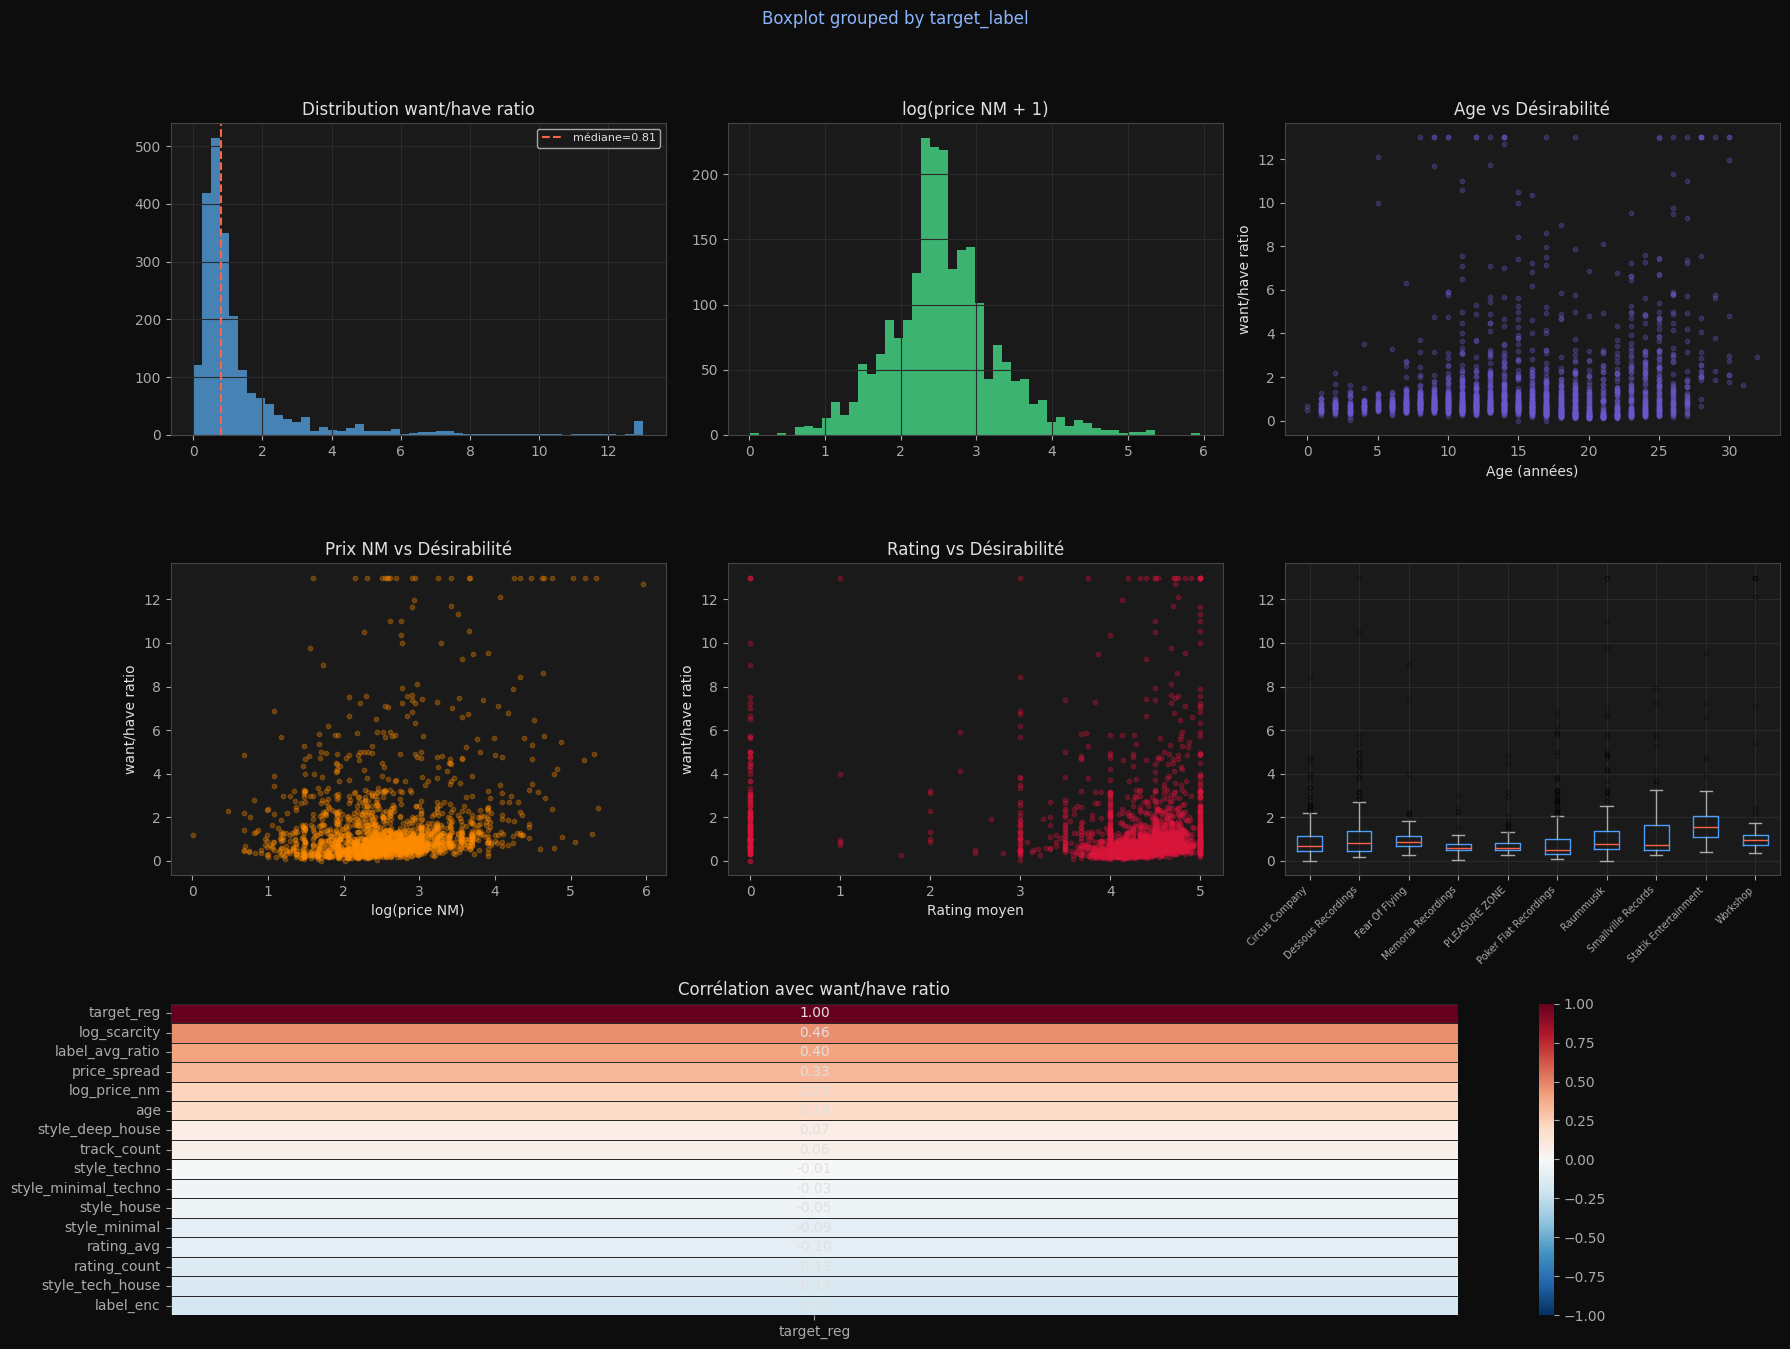

╔════════════════════════════════════════════╗
║   Top 10 corrélations — want_have_ratio    ║
╠════════════════════════════════════════════╣
║    Feature           :  Corrélation  r     ║
╠════════════════════════════════════════════╣
║    log_scarcity      :  +0.461  █████████  ║
║    label_avg_ratio   :  +0.399  ███████    ║
║    price_spread      :  +0.332  ██████     ║
║    log_price_nm      :  +0.230  ████       ║
║    age               :  +0.189  ███        ║
║    label_enc         :  -0.177  ███        ║
║    style_tech_house  :  -0.141  ██         ║
║    rating_count      :  -0.128  ██         ║
║    rating_avg        :  -0.096  █          ║
║    style_minimal     :  -0.094  █          ║
╚════════════════════════════════════════════╝


In [ ]:
# ── EDA — Signaux marchands ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

_dark = {
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a2a',
}

with mpl.rc_context(_dark):
    fig = plt.figure(figsize=(18, 14), facecolor='#0d0d0d')
    fig.suptitle('4.5 — EDA : Signaux marchands vinyl',
                 fontsize=14, fontweight='bold', color='#8ab4f8')

    # 1) Distribution want_have_ratio
    ax1 = fig.add_subplot(3, 3, 1)
    df['target_reg'].hist(bins=50, ax=ax1, color='steelblue', edgecolor='none')
    ax1.axvline(median_ratio, color='tomato', lw=1.5, ls='--',
                label=f'médiane={median_ratio:.2f}')
    ax1.set_facecolor('#1a1a1a')
    ax1.set_title('Distribution want/have ratio', color='#e0e0e0')
    ax1.legend(fontsize=8)

    # 2) Log price_nm distribution
    ax2 = fig.add_subplot(3, 3, 2)
    df['log_price_nm'].hist(bins=50, ax=ax2, color='mediumseagreen', edgecolor='none')
    ax2.set_facecolor('#1a1a1a')
    ax2.set_title('log(price NM + 1)', color='#e0e0e0')

    # 3) Age vs want_have_ratio
    ax3 = fig.add_subplot(3, 3, 3)
    ax3.scatter(df['age'], df['target_reg'], alpha=0.3, s=10, color='slateblue')
    ax3.set_facecolor('#1a1a1a')
    ax3.set_xlabel('Age (années)'); ax3.set_ylabel('want/have ratio')
    ax3.set_title('Age vs Désirabilité', color='#e0e0e0')

    # 4) Price NM vs want_have_ratio
    ax4 = fig.add_subplot(3, 3, 4)
    ax4.scatter(df['log_price_nm'], df['target_reg'], alpha=0.3, s=10, color='darkorange')
    ax4.set_facecolor('#1a1a1a')
    ax4.set_xlabel('log(price NM)'); ax4.set_ylabel('want/have ratio')
    ax4.set_title('Prix NM vs Désirabilité', color='#e0e0e0')

    # 5) Rating vs want_have_ratio
    ax5 = fig.add_subplot(3, 3, 5)
    ax5.scatter(df['rating_avg'].fillna(0), df['target_reg'], alpha=0.3, s=10, color='crimson')
    ax5.set_facecolor('#1a1a1a')
    ax5.set_xlabel('Rating moyen'); ax5.set_ylabel('want/have ratio')
    ax5.set_title('Rating vs Désirabilité', color='#e0e0e0')

    # 6) Want/have par label (boxplot top 10)
    ax6 = fig.add_subplot(3, 3, 6)
    top10_labels = df['target_label'].value_counts().head(10).index
    df_top = df[df['target_label'].isin(top10_labels)]
    df_top.boxplot(column='target_reg', by='target_label', ax=ax6,
                   flierprops=dict(marker='.', alpha=0.3),
                   boxprops=dict(color='#4a9eff'),
                   whiskerprops=dict(color='#aaa'),
                   medianprops=dict(color='tomato'),
                   capprops=dict(color='#aaa'))
    ax6.set_facecolor('#1a1a1a')
    ax6.set_title('Want/have par label (top 10)', color='#e0e0e0')
    ax6.set_xlabel('')
    plt.sca(ax6); plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.title('')

    # 7) Correlation heatmap
    ax7 = fig.add_subplot(3, 3, (7, 9))
    corr_cols = ['target_reg', 'age', 'log_price_nm', 'price_spread', 'log_scarcity', 'label_avg_ratio',
                 'rating_avg', 'rating_count', 'track_count', 'label_enc'] + STYLE_COLS[:6]
    corr_cols = [c for c in corr_cols if c in df.columns]
    corr = df[corr_cols].corr()[['target_reg']].sort_values('target_reg', ascending=False)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax7,
                annot_kws={'color': '#e0e0e0'},
                linecolor='#2a2a2a', linewidths=0.5)
    ax7.set_facecolor('#1a1a1a')
    ax7.set_title('Corrélation avec want/have ratio', color='#e0e0e0')
    ax7.set_ylabel('')
    ax7.tick_params(colors='#aaa')

    fig.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.show()

# ── Top corrélations (trié par |r|, signe conservé) ──────────────────────────
raw_corr        = corr['target_reg'].drop('target_reg')
top_corr        = raw_corr.abs().sort_values(ascending=False).head(10)
top_corr_signed = raw_corr[top_corr.index]

sections_corr = [('Feature', 'Corrélation  r'), None]
for feat, abs_val in top_corr.items():
    signed_val = top_corr_signed[feat]
    bar = '█' * int(abs_val * 20)
    sections_corr.append((feat, f'{signed_val:+.3f}  {bar}'))
print(render_box(sections_corr, title='Top 10 corrélations — want_have_ratio'))


### **4.6 Modélisation**

**Ce que fait cette sous-partie** : Entraîner et comparer plusieurs modèles de ML pour prédire la désirabilité marchande (`want_have_ratio`) et la collectabilité (`is_collectible`), puis diagnostiquer la qualité des prédictions via un residual plot.

**Modèles évalués** :

| Modèle | Type | Pourquoi |
|---|---|---|
| `Ridge` | Régression linéaire régularisée | Baseline interprétable, sensible aux features linéaires |
| `RandomForestRegressor` | Ensemble (bagging) | Capture les non-linéarités, robuste aux outliers |
| `GradientBoostingRegressor` | Boosting séquentiel | Meilleure performance générale sur données tabulaires |
| `RidgeClassifier` | Classification linéaire | Baseline clf, comparaison avec les ensembles |
| `RandomForestClassifier` | Ensemble (bagging) | Référence non-linéaire |
| `GradientBoostingClassifier` | Boosting séquentiel | Meilleur clf attendu |

**Métriques** :
- Régression : `R²` (variance expliquée), `MAE` (erreur absolue moyenne), `RMSE` (pénalise les grandes erreurs)
- Classification : `Balanced Accuracy` (robuste aux classes déséquilibrées), `F1`, `ROC-AUC`

**Residual plot (OOS)** :
- Les résidus sont calculés via `cross_val_predict` (prédictions hors-échantillon) — honnêtes, sans overfitting in-sample
- **Résidus vs Prédiction** : révèle l'hétéroscédasticité — le modèle est moins précis sur les ratios très élevés (peu d'exemples extrêmes)
- **Distribution des résidus** : doit être centrée sur 0, sans biais systématique

&nbsp;

> **Note** : Cross-validation 5-fold pour les deux tâches. Le meilleur modèle est ensuite entraîné sur l'ensemble du dataset pour l'étape SHAP (5.7).

╔═════════════════════════════════════════════════════════╗
║       5.6 Régression — want_have_ratio (CV 5-fold)      ║
╠═════════════════════════════════════════════════════════╣
║    Modèle              :  R²        MAE       RMSE      ║
╠═════════════════════════════════════════════════════════╣
║      Ridge             :     0.415     0.833     1.477  ║
║    ★ RandomForest      :     0.674     0.519     1.099  ║
║      GradientBoosting  :     0.643     0.548     1.154  ║
╚═════════════════════════════════════════════════════════╝

╔═════════════════════════════════════════════════════════╗
║     5.6 Classification — is_collectible (CV 5-fold)     ║
╠═════════════════════════════════════════════════════════╣
║    Modèle              :  Bal.Acc   F1        ROC-AUC   ║
╠═════════════════════════════════════════════════════════╣
║      RidgeClf          :     0.781     0.771     0.855  ║
║      RandomForest      :     0.838     0.836     0.921  ║
║    ★ GradientBoosting  :     0.844   

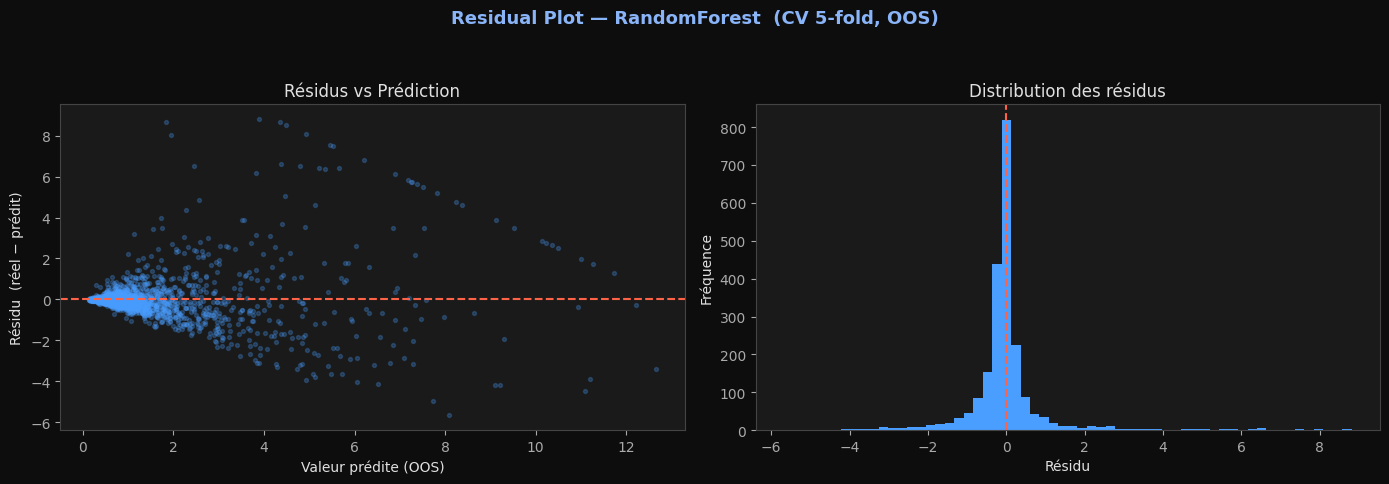

In [ ]:
# ── Modélisation ──────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge, RidgeClassifier
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              RandomForestClassifier, GradientBoostingClassifier)
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, balanced_accuracy_score
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bal_acc = make_scorer(balanced_accuracy_score)

reg_models = {
    'Ridge':            Pipeline([('sc', StandardScaler()), ('m', Ridge())]),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
}
clf_models = {
    'RidgeClf':         Pipeline([('sc', StandardScaler()), ('m', RidgeClassifier())]),
    'RandomForest':     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
}

# ── Régression ────────────────────────────────────────────────────────────────
reg_results = {}
for name, model in reg_models.items():
    r2   = cross_val_score(model, X, y_reg, cv=cv_reg, scoring='r2').mean()
    mae  = -cross_val_score(model, X, y_reg, cv=cv_reg, scoring='neg_mean_absolute_error').mean()
    rmse = (-cross_val_score(model, X, y_reg, cv=cv_reg, scoring='neg_root_mean_squared_error')).mean()
    reg_results[name] = {'R²': r2, 'MAE': mae, 'RMSE': rmse}

# ── Classification ────────────────────────────────────────────────────────────
clf_results = {}
for name, model in clf_models.items():
    ba  = cross_val_score(model, X, y_clf, cv=cv_clf, scoring=bal_acc).mean()
    f1  = cross_val_score(model, X, y_clf, cv=cv_clf, scoring='f1').mean()
    try:    auc = cross_val_score(model, X, y_clf, cv=cv_clf, scoring='roc_auc').mean()
    except: auc = float('nan')
    clf_results[name] = {'Bal.Acc': ba, 'F1': f1, 'ROC-AUC': auc}

# ── Meilleurs modèles ─────────────────────────────────────────────────────────
best_reg_name = max(reg_results, key=lambda k: reg_results[k]['R²'])
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['Bal.Acc'])

# ── Affichage ─────────────────────────────────────────────────────────────────
def winner(name, all_results, metric):
    best = max(all_results, key=lambda k: all_results[k][metric])
    return '★' if name == best else ' '

sec_reg = [('Modèle', 'R²        MAE       RMSE'), None]
for name, res in reg_results.items():
    w = winner(name, reg_results, 'R²')
    sec_reg.append((f'{w} {name}', f'{res["R²"]:>8.3f}  {res["MAE"]:>8.3f}  {res["RMSE"]:>8.3f}'))

sec_clf = [('Modèle', 'Bal.Acc   F1        ROC-AUC'), None]
for name, res in clf_results.items():
    w   = winner(name, clf_results, 'Bal.Acc')
    auc = f'{res["ROC-AUC"]:>8.3f}' if res["ROC-AUC"] == res["ROC-AUC"] else '     n/a'
    sec_clf.append((f'{w} {name}', f'{res["Bal.Acc"]:>8.3f}  {res["F1"]:>8.3f}  {auc}'))

sec_winner = [
    ('Régression',     f'{best_reg_name}  (R²={reg_results[best_reg_name]["R²"]:.3f})'),
    ('Classification', f'{best_clf_name}  (Bal.Acc={clf_results[best_clf_name]["Bal.Acc"]:.3f})'),
]

print(render_box(sec_reg,    title='4.6 Régression — want_have_ratio (CV 5-fold)'))
print()
print(render_box(sec_clf,    title='4.6 Classification — is_collectible (CV 5-fold)'))
print()
print(render_box(sec_winner, title='Meilleurs modèles ★'))

# ── Entraînement final ────────────────────────────────────────────────────────
best_reg = reg_models[best_reg_name]
best_clf = clf_models[best_clf_name]
best_reg.fit(X, y_reg)
best_clf.fit(X, y_clf)

# ── Residual plot (prédictions OOS via cross_val_predict) ─────────────────────
y_pred_oos = cross_val_predict(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    if best_reg_name == 'RandomForest' else
    GradientBoostingRegressor(n_estimators=200, random_state=42)
    if best_reg_name == 'GradientBoosting' else
    Pipeline([('sc', StandardScaler()), ('m', Ridge())]),
    X, y_reg, cv=cv_reg
)
residuals = y_reg.values - y_pred_oos

_dark = {
    'figure.facecolor': '#0d0d0d', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaa', 'ytick.color': '#aaa',
    'text.color': '#e0e0e0', 'grid.color': '#2a2a2a',
}
with mpl.rc_context(_dark):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')

    # 1) Résidus vs valeurs prédites
    axes[0].scatter(y_pred_oos, residuals, alpha=0.25, s=8, color='#4a9eff')
    axes[0].axhline(0, color='tomato', lw=1.5, ls='--')
    axes[0].set_xlabel('Valeur prédite (OOS)')
    axes[0].set_ylabel('Résidu  (réel − prédit)')
    axes[0].set_title('Résidus vs Prédiction', color='#e0e0e0')

    # 2) Distribution des résidus
    axes[1].hist(residuals, bins=60, color='#4a9eff', edgecolor='none')
    axes[1].axvline(0, color='tomato', lw=1.5, ls='--')
    axes[1].set_xlabel('Résidu')
    axes[1].set_ylabel('Fréquence')
    axes[1].set_title('Distribution des résidus', color='#e0e0e0')

    fig.suptitle(f'Residual Plot — {best_reg_name}  (CV 5-fold, OOS)',
                 fontsize=13, fontweight='bold', color='#8ab4f8')
    fig.tight_layout(rect=[0, 0.02, 1, 0.93])
    plt.show()

### **4.7 Interprétabilité SHAP**

**Ce que fait cette sous-partie** : Expliquer les prédictions du meilleur modèle de régression via SHAP (SHapley Additive exPlanations) pour comprendre quels facteurs déterminent la collectabilité d'un vinyl.

**Visualisations produites** :

| Plot | Ce qu'on lit |
|---|---|
| Summary bar (importance globale) | Classement des features par impact moyen absolu sur toutes les prédictions |
| Summary beeswarm (directionnel) | Direction de l'impact : rouge = valeur haute de la feature → ratio ↑, bleu → ratio ↓ |
| Waterfall [MAX] | Déconstruction de la prédiction pour le vinyl le plus convoité du corpus |
| Waterfall [MÉDIANE] | Déconstruction pour un vinyl "typique" (proche de la médiane) |
| Waterfall [MIN] | Déconstruction pour le vinyl le moins convoité — signaux inverses |

**Comment lire un waterfall** :
- `E[f(X)]` = valeur de base (prédiction moyenne du modèle sur tout le corpus)
- `f(x)` = prédiction pour cette release spécifique
- Chaque barre = contribution d'une feature : **rose** = pousse vers le haut, **bleu** = pousse vers le bas
- La valeur à gauche = valeur réelle de la feature pour cette release

**Patterns observés** :
- `log_scarcity` est systématiquement la feature dominante — la rareté relative (want/copies en vente) explique l'essentiel de la variance
- `label_avg_ratio` reflète la niche du label — un label de niche amplifie la collectabilité indépendamment du disque
- `rating_count` a un effet négatif — les disques très notés sont souvent les plus répandus (paradoxe popularité/rareté)

&nbsp;

> **Note** : SHAP utilise `TreeExplainer` pour les modèles à arbres (RandomForest, GradientBoosting), `LinearExplainer` pour Ridge. Si le meilleur modèle est un `Pipeline`, l'estimateur final est extrait automatiquement.

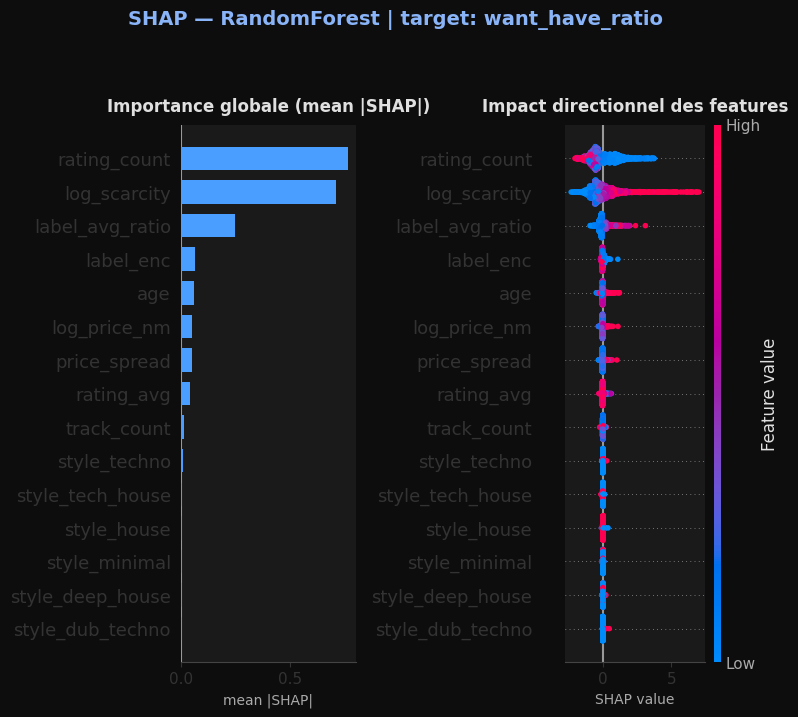

╔════════════════════════════════════════════╗
║               Release [MAX]                ║
╠════════════════════════════════════════════╣
║    Artist Names     :  Baby Pop            ║
║    Title            :  Minimal Structures  ║
║    Target Label     :  Tetrode Music       ║
║    Released Year    :  1996                ║
║    Want Have Ratio  :  29.26               ║
║    Price Nm         :  178.02              ║
║    Price Currency   :  EUR                 ║
╚════════════════════════════════════════════╝


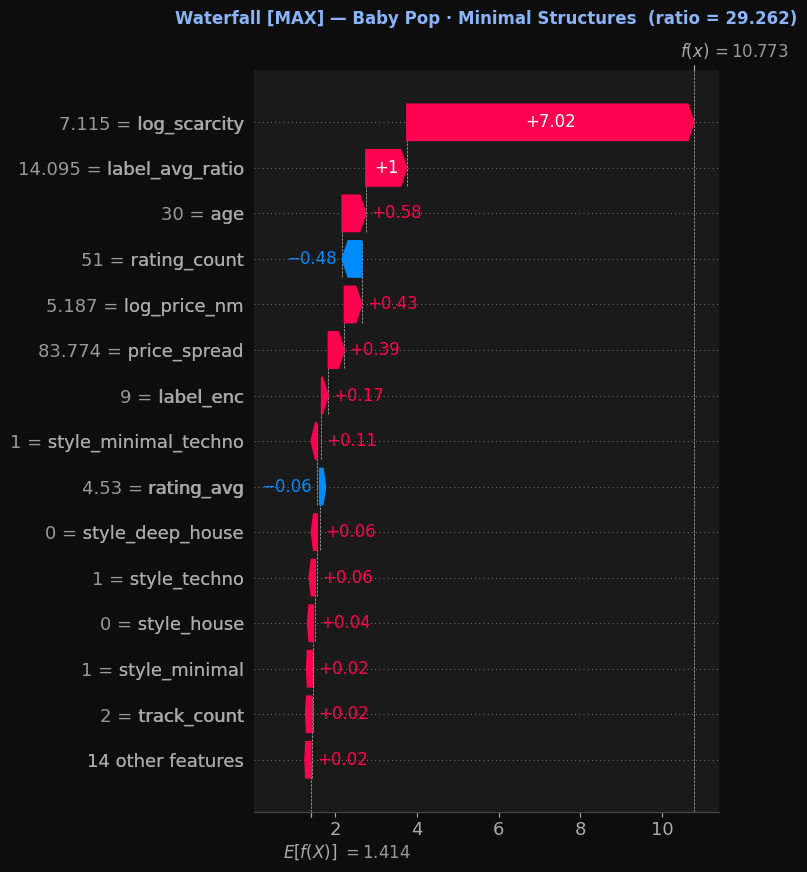

╔════════════════════════════════════════════╗
║             Release [MEDIANE]              ║
╠════════════════════════════════════════════╣
║    Artist Names     :  Martinez            ║
║    Title            :  Skywalker EP        ║
║    Target Label     :  Dessous Recordings  ║
║    Released Year    :  2003                ║
║    Want Have Ratio  :  0.81                ║
║    Price Nm         :  22.92               ║
║    Price Currency   :  EUR                 ║
╚════════════════════════════════════════════╝


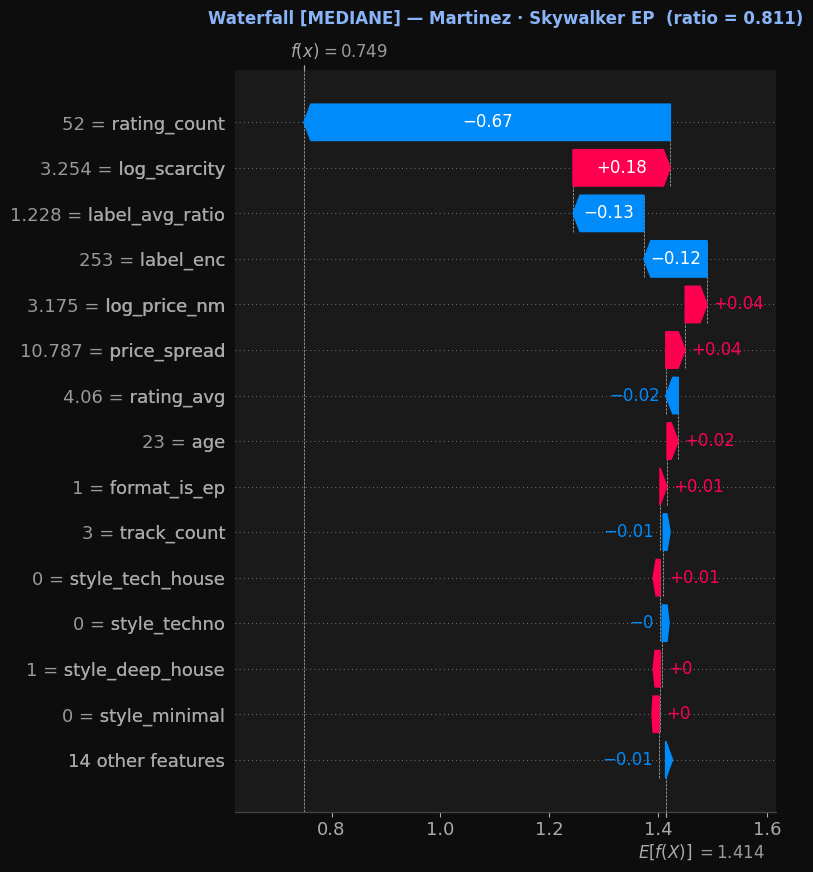

╔═══════════════════════════════════════════════╗
║                 Release [MIN]                 ║
╠═══════════════════════════════════════════════╣
║    Artist Names     :  Marc Schneider|Aera    ║
║    Title            :  The Taylor & Smith EP  ║
║    Target Label     :  Circus Company         ║
║    Released Year    :  2011                   ║
║    Want Have Ratio  :  0.00                   ║
║    Price Nm         :  6.54                   ║
║    Price Currency   :  EUR                    ║
╚═══════════════════════════════════════════════╝


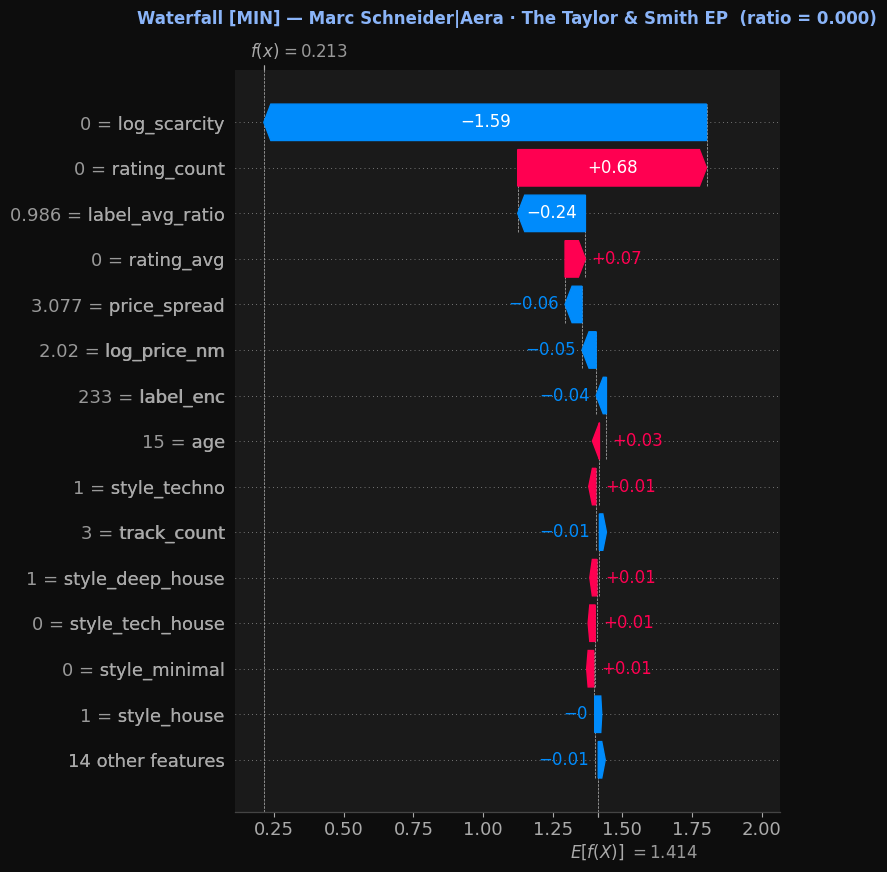

In [ ]:
# ── Interprétabilité SHAP ────────────────────────────────────────────────
import shap
import matplotlib.pyplot as plt
import matplotlib as mpl

_dark = {
    'figure.facecolor': '#0d0d0d', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',      'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaa',         'ytick.color': '#aaa',
    'text.color': '#e0e0e0',       'grid.color': '#2a2a2a',
}

# ── Récupérer l'estimateur final (hors Pipeline) ──────────────────────────────
def unwrap(model):
    return model.named_steps['m'] if hasattr(model, 'named_steps') else model

estimator = unwrap(best_reg)
X_shap    = X.copy()

if hasattr(best_reg, 'named_steps') and 'sc' in best_reg.named_steps:
    X_shap = pd.DataFrame(
        best_reg.named_steps['sc'].transform(X),
        columns=X.columns
    )

# ── Explainer ─────────────────────────────────────────────────────────────────
if hasattr(estimator, 'estimators_'):
    explainer   = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_shap)
else:
    explainer   = shap.LinearExplainer(estimator, X_shap)
    shap_values = explainer.shap_values(X_shap)

base_val = explainer.expected_value
if hasattr(base_val, '__len__'):
    base_val = float(base_val[0])
else:
    base_val = float(base_val)

# ── Summary plot ──────────────────────────────────────────────────────────────
with mpl.rc_context(_dark):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor='#0d0d0d')

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_shap, plot_type='bar',
                      max_display=15, show=False, color='#4a9eff')
    axes[0].set_facecolor('#1a1a1a')
    axes[0].set_title('Importance globale (mean |SHAP|)',
                      fontweight='bold', color='#e0e0e0', pad=10)
    axes[0].set_xlabel('mean |SHAP|', color='#aaa', fontsize=10)

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
    axes[1].set_facecolor('#1a1a1a')
    axes[1].set_title('Impact directionnel des features',
                      fontweight='bold', color='#e0e0e0', pad=10)
    axes[1].set_xlabel('SHAP value', color='#aaa', fontsize=10)

    fig.suptitle('SHAP — ' + best_reg_name + ' | target: want_have_ratio',
                 fontsize=14, fontweight='bold', color='#8ab4f8')
    fig.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

# ── Waterfall helper ──────────────────────────────────────────────────────────
def _fmt_val(col, val):
    if col == 'released_year':
        return str(int(val))
    if col in ('price_nm', 'want_have_ratio'):
        return '{:.2f}'.format(float(val))
    return str(val)

def plot_waterfall(idx, label, shap_values_arr, X_shap_df, df_src):
    row    = df_src.loc[idx]
    pos    = X_shap_df.index.get_loc(idx)
    shap_exp = shap.Explanation(
        values        = shap_values_arr[pos],
        base_values   = base_val,
        data          = X_shap_df.loc[idx].values,
        feature_names = X_shap_df.columns.tolist()
    )
    artist = str(row.get('artist_names', '?'))[:45]
    title  = str(row.get('title', '?'))[:45]
    ratio  = row.get('want_have_ratio', float('nan'))

    sec = [
        (col.replace('_', ' ').title(), _fmt_val(col, row[col]))
        for col in ['artist_names', 'title', 'target_label',
                    'released_year', 'want_have_ratio', 'price_nm', 'price_currency']
        if col in row and str(row[col]) not in ('nan', 'None')
    ]
    print(render_box(sec, title='Release [' + label + ']'))

    ratio_str = '{:.3f}'.format(ratio) if ratio == ratio else '?'
    plot_title = 'Waterfall [' + label + '] — ' + artist + ' · ' + title + '  (ratio = ' + ratio_str + ')'

    with mpl.rc_context(_dark):
        fig = plt.figure(figsize=(14, 7), facecolor='#0d0d0d')
        shap.plots.waterfall(shap_exp, max_display=15, show=False)
        ax = plt.gca()
        ax.set_facecolor('#1a1a1a')
        plt.title(plot_title, color='#8ab4f8', fontweight='bold', pad=12)
        plt.tight_layout(rect=[0, 0.02, 1, 1])
        plt.show()

# ── 3 cas : MAX / MEDIANE / MIN ───────────────────────────────────────────────
top_idx = y_reg.idxmax()
med_idx = (y_reg - y_reg.median()).abs().idxmin()
bot_idx = y_reg.idxmin()

plot_waterfall(top_idx, 'MAX',     shap_values, X_shap, df)
plot_waterfall(med_idx, 'MEDIANE', shap_values, X_shap, df)
plot_waterfall(bot_idx, 'MIN',     shap_values, X_shap, df)

---
## **Partie 5 — Conclusions**

### **5.1 La collectabilité d'un vinyl se prédit**

La question ici change de nature : on ne cherche plus à *classer* des releases, mais à *mesurer* leur désirabilité marchande. La variable cible est le **want/have ratio** — le rapport entre le nombre de personnes qui veulent un vinyl et le nombre qui le possèdent déjà. Un ratio de 5 signifie que pour chaque propriétaire, 5 personnes le cherchent. Un ratio de 0 signifie que personne ne le veut activement.

Pour alimenter ce modèle, on ne peut pas se contenter du CSV — il ne contient pas ces signaux marchands. On les a collectés via l'**API Discogs** sur 2 139 releases vinyl ciblées. C'est un sous-ensemble, mais il est réel et directement extrait de la plateforme.

**Qu'est-ce que R² = 0.674 veut dire concrètement ?**
Le R² mesure la part de la variance que le modèle réussit à expliquer. Sur une échelle de 0 (le modèle ne comprend rien) à 1 (le modèle est parfait), obtenir **0.674** signifie que **67% des différences de désirabilité** entre les vinyls sont capturées par les métadonnées disponibles. Le modèle n'est pas parfait — les 33% restants correspondent à des facteurs que les données ne permettent pas de mesurer : la notoriété actuelle d'un artiste, un passage en playlist, une tendance passagère, ou simplement la subjectivité des collectionneurs.

**Pourquoi la régression linéaire (Ridge, R²=0.415) est-elle nettement moins bonne ?**
Un modèle linéaire suppose que chaque variable contribue indépendamment et proportionnellement à la désirabilité. Or la réalité est plus complexe : un vinyl ancien *et* issu d'un label de niche *et* peu disponible n'a pas une désirabilité qui est juste la somme de ces trois effets — elle est bien supérieure. Ces **interactions non-linéaires** sont exactement ce que le RandomForest capture, et la régression linéaire ne peut pas.

**Qu'est-ce que ROC-AUC = 0.921 veut dire ?**
Pour la classification binaire (collectible ou non), le ROC-AUC mesure la capacité du modèle à distinguer les deux classes. Une valeur de 0.921 signifie que si tu prends au hasard un vinyl "collectible" et un vinyl "non collectible" et que tu demandes au modèle lequel est lequel, il se trompe moins d'une fois sur dix. C'est un score élevé — surtout sur un dataset aussi petit (2 139 lignes).

&nbsp;

> **En résumé** : Les métadonnées d'une release — son label, son ancienneté, son prix, sa rareté — contiennent suffisamment d'information pour prédire sa désirabilité dans **deux tiers des cas**. Ce n'est pas de la magie : c'est la traduction quantitative de ce que les collectionneurs savent instinctivement. Le modèle apprend leurs préférences depuis les données.

### **5.2 Ce qui fait qu'un vinyl vaut de l'or**

Un modèle prédictif, c'est bien. Savoir *pourquoi* il prédit ce qu'il prédit, c'est mieux. C'est le rôle de **SHAP** (SHapley Additive exPlanations) : déconstruire chaque prédiction en la décomposant en contributions individuelles de chaque variable. Pour chaque release, SHAP répond à la question : *"Qu'est-ce qui pousse ce vinyl vers le haut ou vers le bas dans la prédiction ?"*

**Les deux variables qui dominent :**

- **`log_scarcity`** — l'indice de rareté brute : combien d'exemplaires sont actuellement en vente, rapporté au nombre de personnes qui le possèdent. Un vinyl dont très peu d'exemplaires circulent mais que beaucoup de gens ont — c'est le signal le plus fort de désirabilité. Les collectionneurs ne le lâchent pas, et ceux qui n'en ont pas sont prêts à payer.

- **`label_avg_ratio`** — la réputation moyenne du label : si les autres releases de ce label sont en moyenne très recherchées, la nouvelle release bénéficie d'un "halo de label". C'est la logique de Warp, Kompakt ou Tetrode : leur nom porte une promesse de qualité que le marché a apprise à valoriser.

**3 cas concrets pour illustrer :**

&nbsp;

🔺 **Le plus désiré du corpus** : *Baby Pop — Minimal Structures* (Tetrode Music, 1996)

- **Want/have ratio : 29.26** — pour chaque personne qui possède ce vinyl, 29 le cherchent.
- **Prix : 178 €** en état Near Mint.
- Pourquoi ? Pressing de 1996 sur un label confidentiel, tirage limité, jamais réédité. SHAP montre que `log_scarcity` et `label_avg_ratio` tirent fortement le score vers le haut. L'ancienneté joue aussi : les vinyls pre-2000 ont en moyenne des ratios plus élevés parce que les pressages étaient plus petits et beaucoup ont été perdus ou abîmés.

&nbsp;

➖ **Le vinyl médian** : *Martinez — Skywalker EP* (Dessous Recordings, 2003)

- **Want/have ratio : 0.81** — légèrement plus de demandeurs que de possesseurs. Un vinyl "normal" dans le marché : il circule, il se trouve, il ne s'arrache pas.
- **Prix : 22 €**.
- Dessous Recordings est un label sérieux mais avec un catalogue conséquent. La rareté est faible, le label n'a pas de halo particulier. SHAP ne trouve pas de signal fort dans un sens ou dans l'autre — prédiction centrale.

&nbsp;

🔻 **Le moins désiré** : *Marc Schneider & Aera — The Taylor & Smith EP* (Circus Company, 2011)

- **Want/have ratio : 0.00** — personne ne le cherche activement, ou presque.
- **Prix : 6 €**.
- Release de 2011, label relativement récent, peu de copies vendues, prix bas. SHAP montre que tous les facteurs tirent vers le bas : faible `log_scarcity` (beaucoup de copies disponibles par rapport au nombre de propriétaires), `label_avg_ratio` bas (Circus Company n'a pas de réputation de collectabilité), release récente. Aucun signal de rareté, aucun halo de label.

&nbsp;

> **La leçon du SHAP** : ce qui crée la valeur marchande d'un vinyl, c'est une combinaison de **rareté physique** (peu d'exemplaires en circulation), de **réputation du label** (les collectionneurs savent que certains labels produisent systématiquement des objets désirables), et d'**ancienneté** (les vinyls des années 90 et début 2000 ont souvent des tirages que personne n'a pensé à conserver à l'époque). Ces trois facteurs ne s'additionnent pas — ils se multiplient.

&nbsp;

> **Limite à garder en tête** : ces conclusions sont solides sur les 2 139 releases enrichies. Elles capturent les signaux réels du marché Discogs à la date du snapshot (01/02/2026). Mais want/have évolue en permanence — une release peut devenir culte du jour au lendemain après un passage en podcast ou une réédition annoncée. Le modèle photographie un état du marché, il ne prédit pas son futur.